In [ ]:
!pip install scikit-image matplotlib

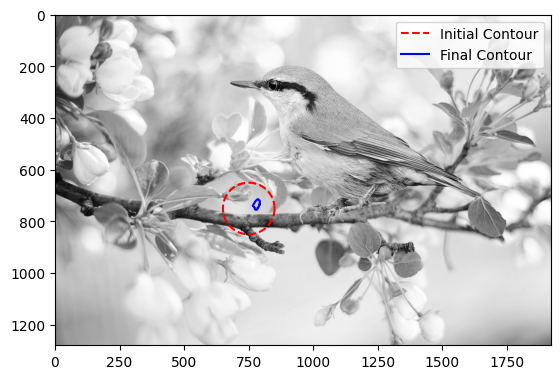

In [14]:
import numpy as np
import cv2
from skimage.segmentation import active_contour
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('bird.jpg', 0)  # Read in grayscale

# Create initial contour (e.g., circle)
s = np.linspace(0, 2*np.pi, 100)
x = 750 + 100*np.cos(s)
y = 750 + 100*np.sin(s)
init = np.array([x, y]).T

# Apply Active Contour Model (Snake)
snake = active_contour(image, init, alpha=0.015, beta=10, gamma=0.001)

# Plot results
fig, ax = plt.subplots()
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(init[:, 0], init[:, 1], '--r', label='Initial Contour')
ax.plot(snake[:, 0], snake[:, 1], '-b', label='Final Contour')
ax.legend()
plt.show()


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color
from skimage.filters import gaussian
from skimage.segmentation import active_contour

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

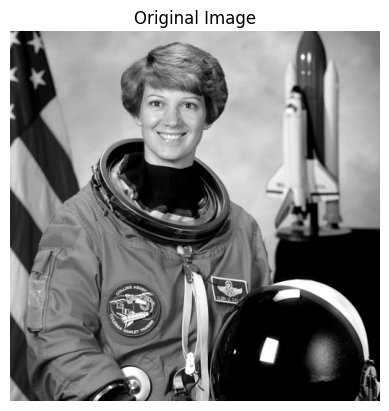

In [13]:
image = color.rgb2gray(data.astronaut())

plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

In [3]:
s = np.linspace(0, 2*np.pi, 400)
r = 100 + 100*np.sin(s)
c = 220 + 100*np.cos(s)

init = np.array([r, c]).T

In [4]:
snake = active_contour(
    gaussian(image, 3),
    init,
    alpha=0.015,
    beta=10,
    gamma=0.001
)

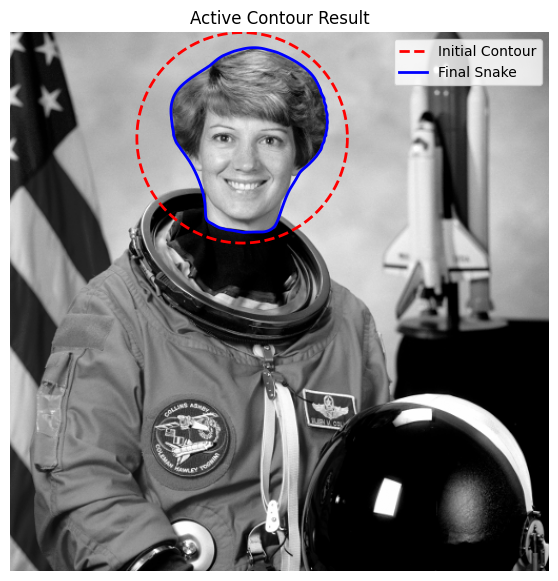

In [5]:
fig, ax = plt.subplots(figsize=(7,7))

ax.imshow(image, cmap='gray')
ax.plot(init[:,1], init[:,0], '--r', lw=2, label='Initial Contour')
ax.plot(snake[:,1], snake[:,0], '-b', lw=2, label='Final Snake')

ax.set_title("Active Contour Result")
ax.axis('off')
ax.legend()

plt.show()

Dynamic snakes and Condensation

In [15]:
import cv2
import numpy as np

width, height = 400, 400

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('video.mp4', fourcc, 20.0, (width, height))

for i in range(200):

    # black background
    frame = np.zeros((height, width, 3), dtype=np.uint8)

    # moving white rectangle
    x = 100 + i//2
    y = 150

    cv2.rectangle(frame, (x, y), (x+50, y+50), (255,255,255), -1)

    out.write(frame)

out.release()
print("video.mp4 created successfully")


video.mp4 created successfully


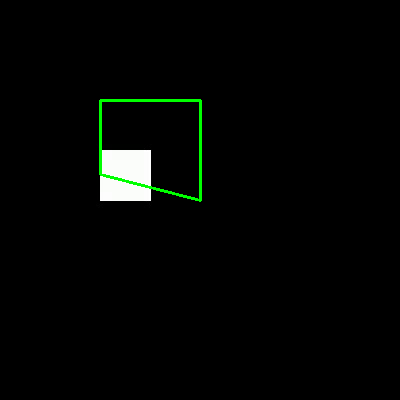

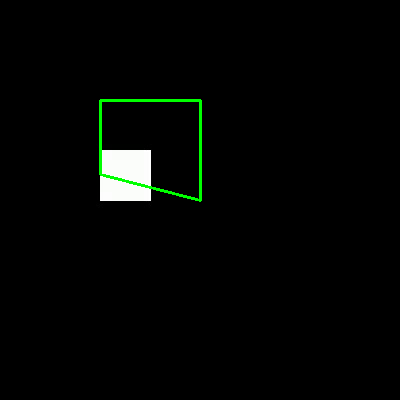

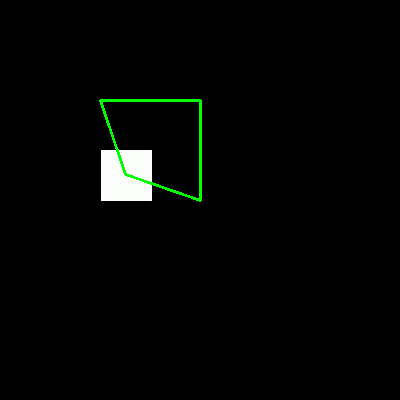

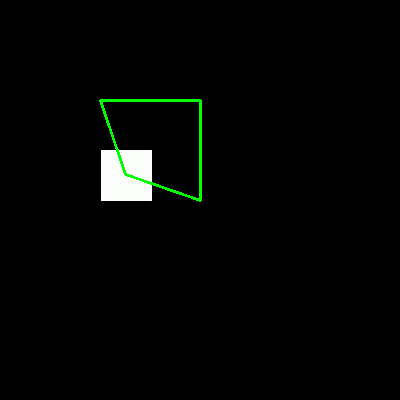

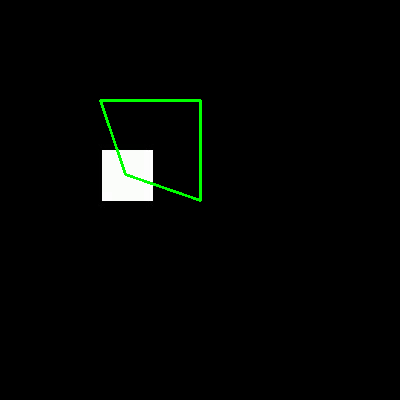

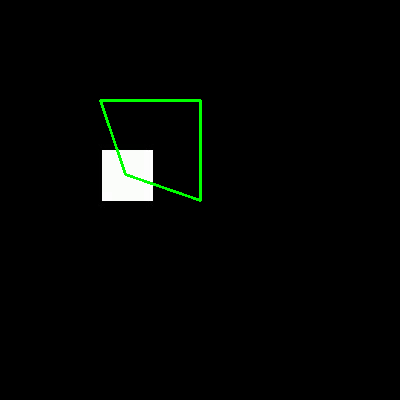

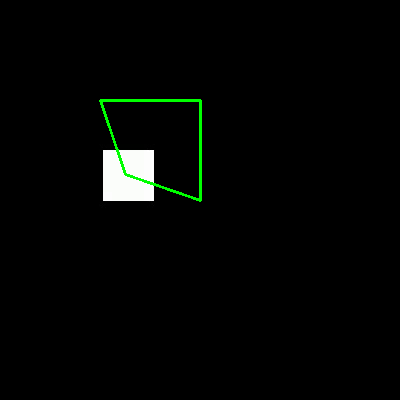

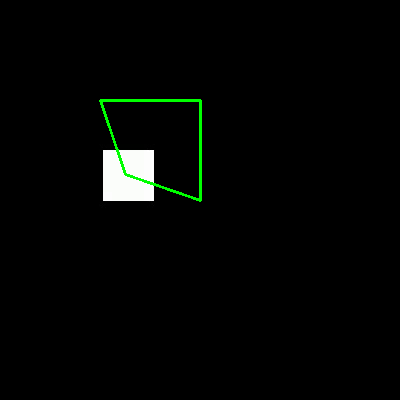

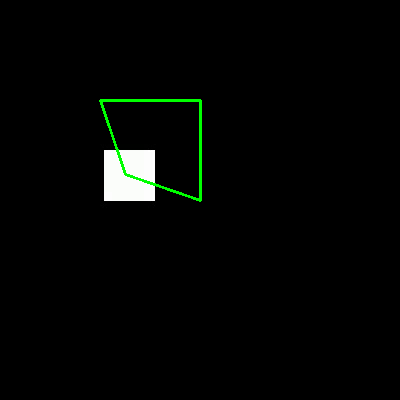

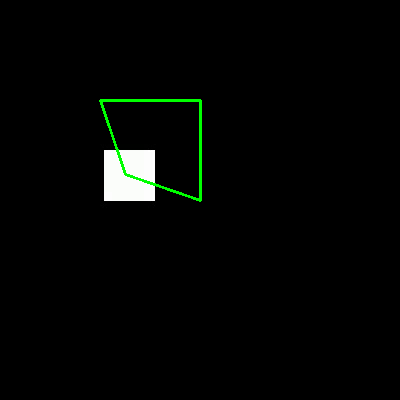

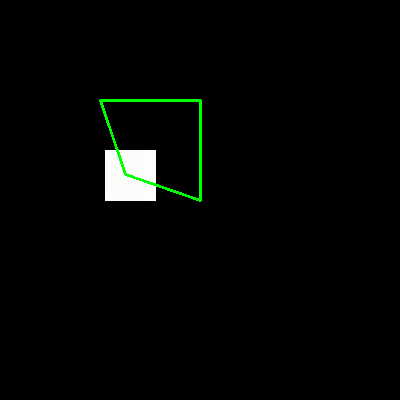

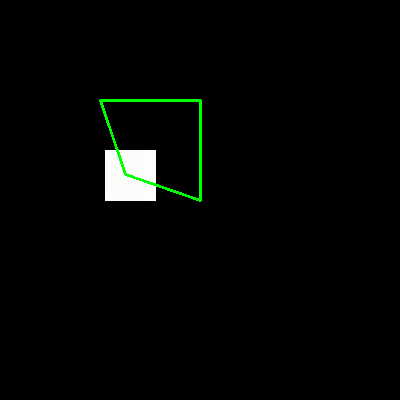

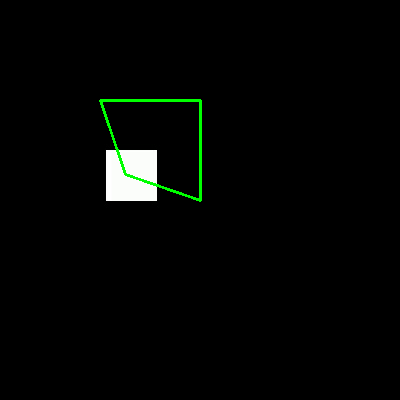

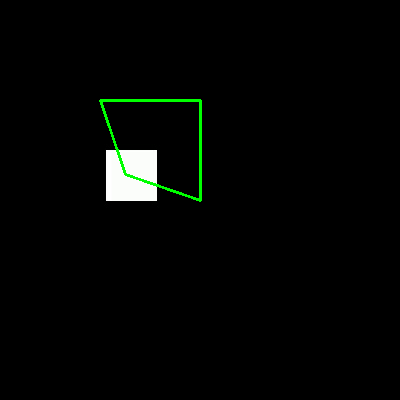

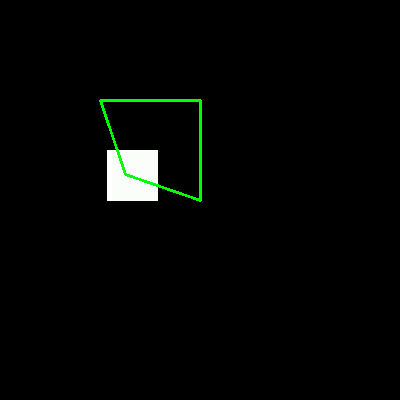

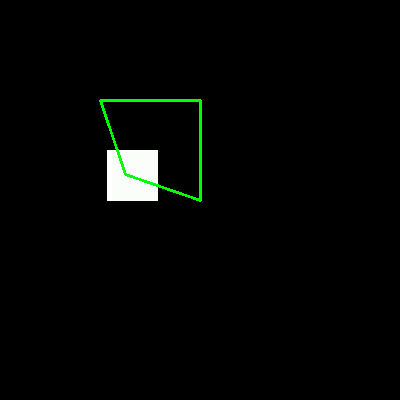

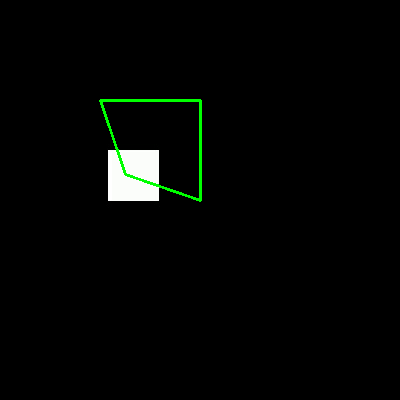

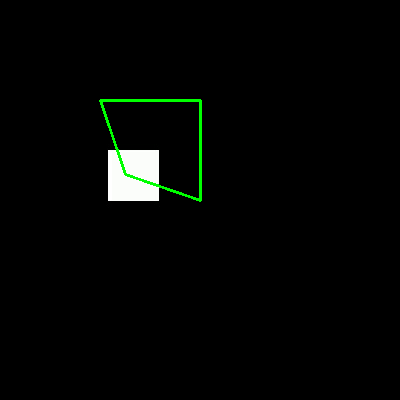

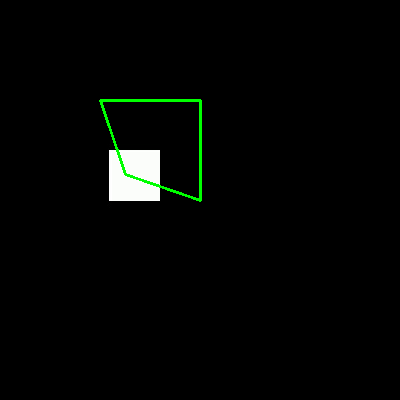

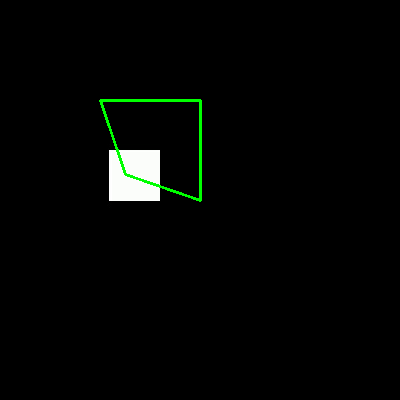

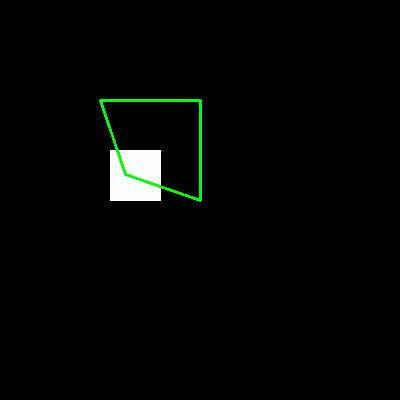

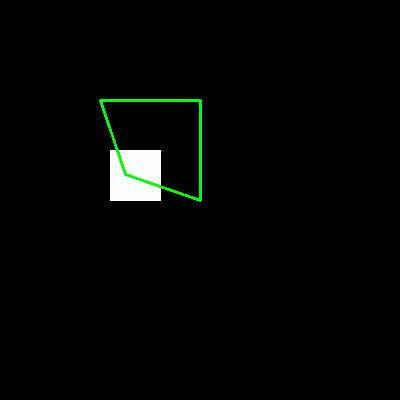

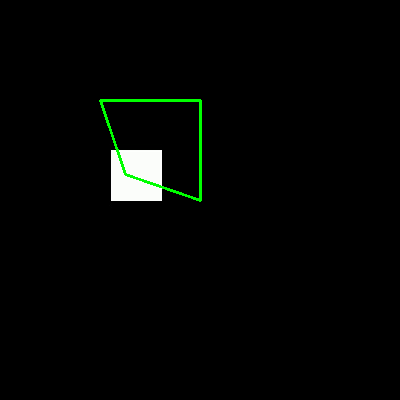

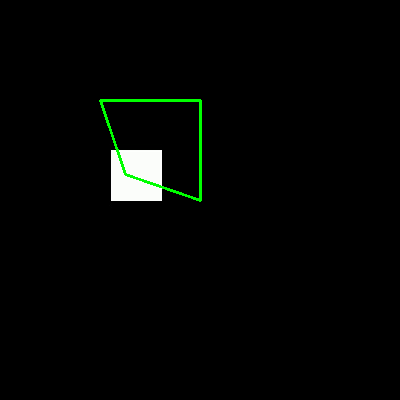

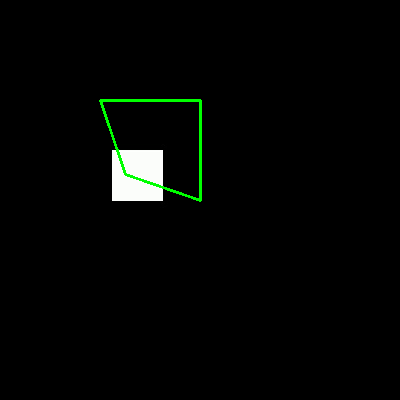

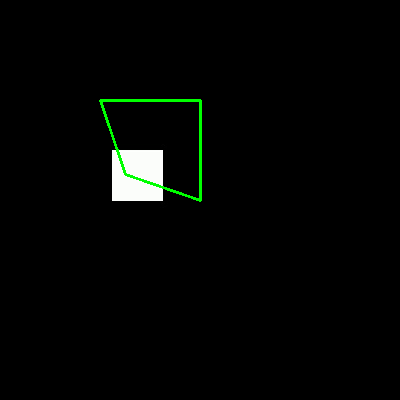

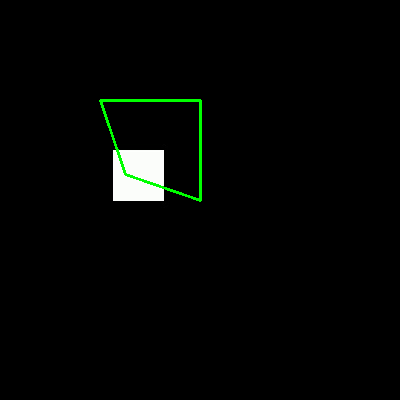

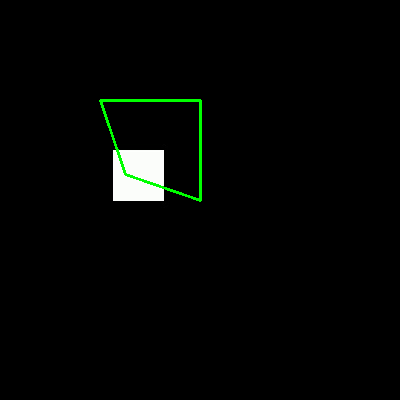

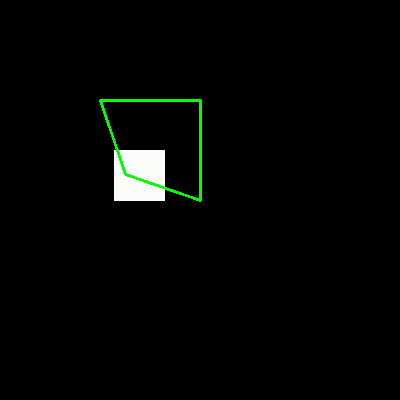

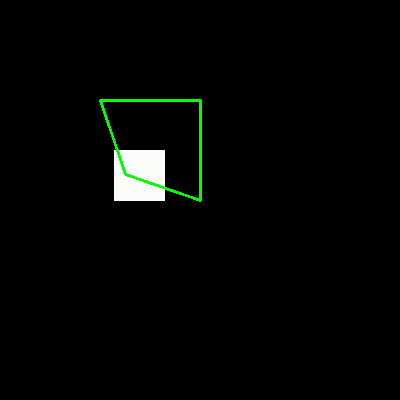

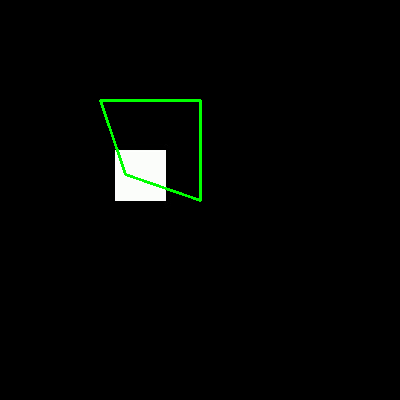

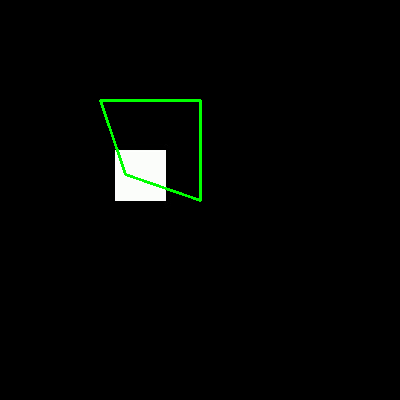

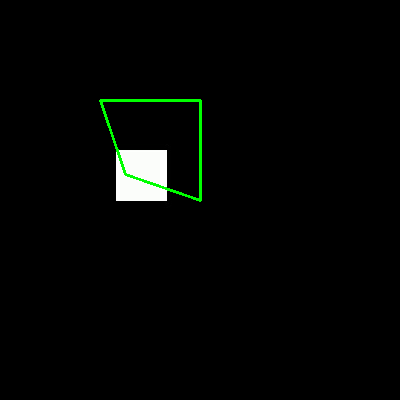

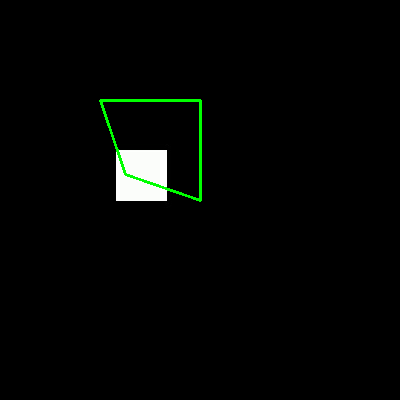

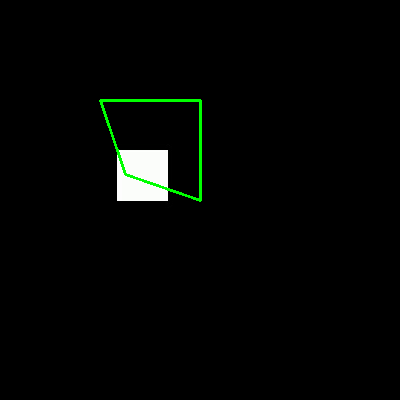

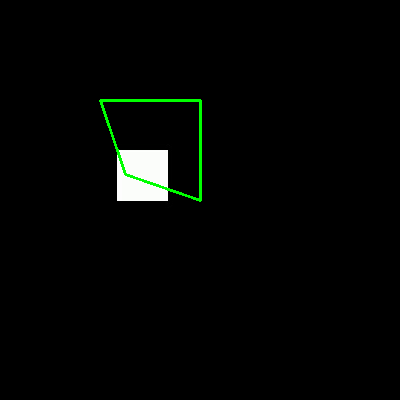

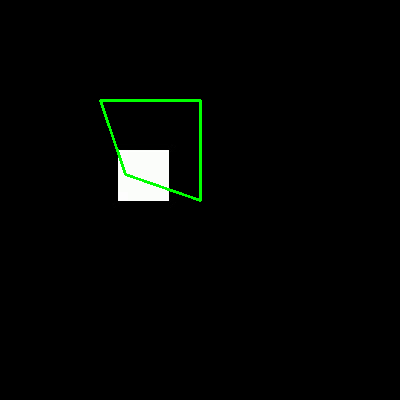

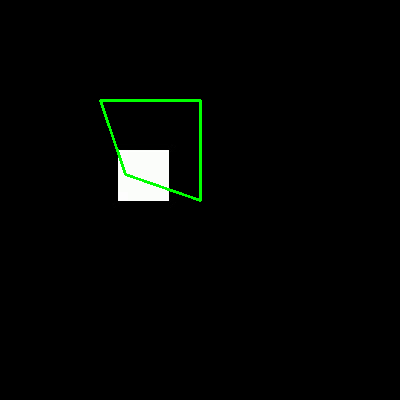

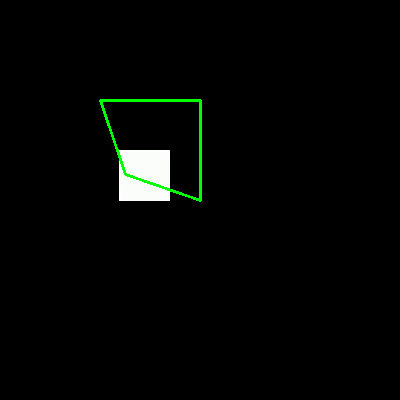

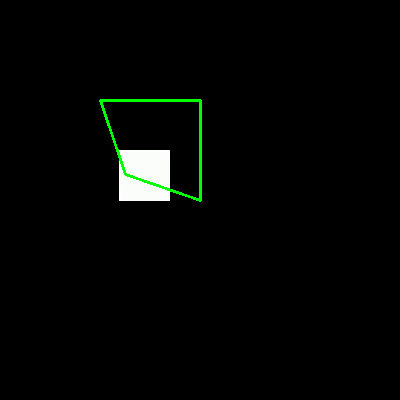

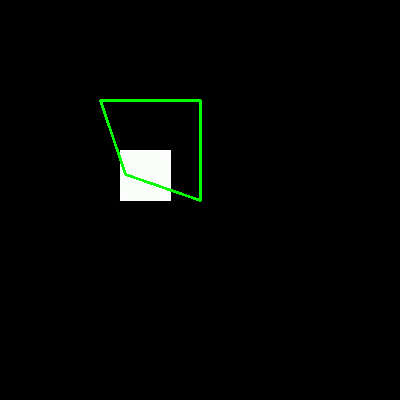

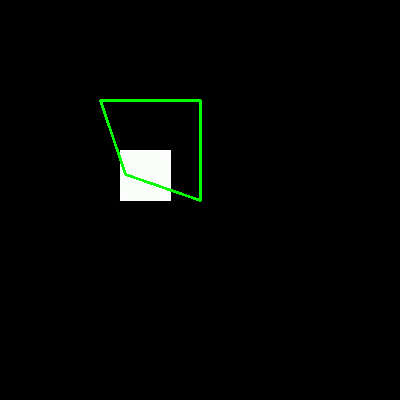

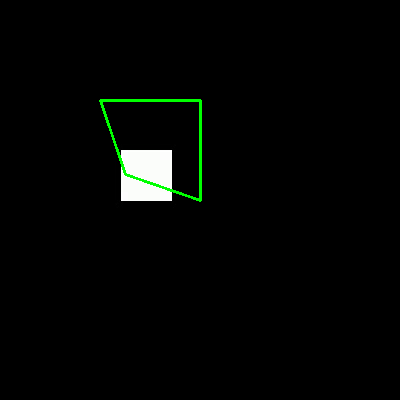

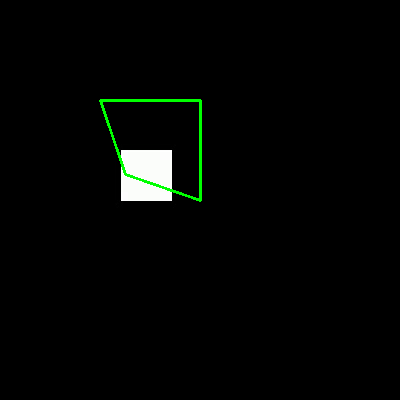

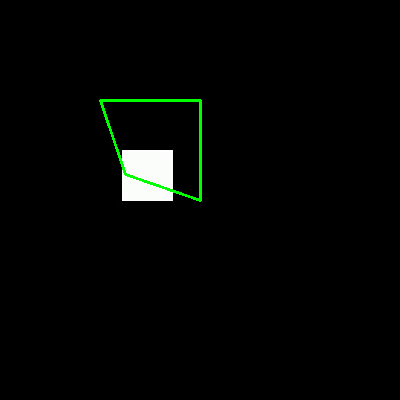

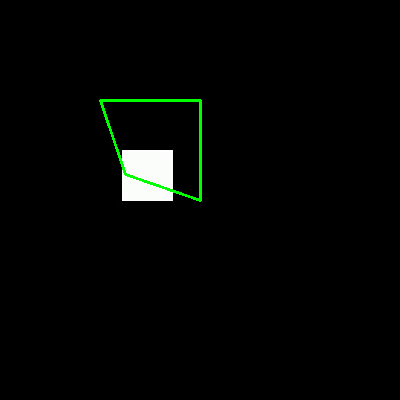

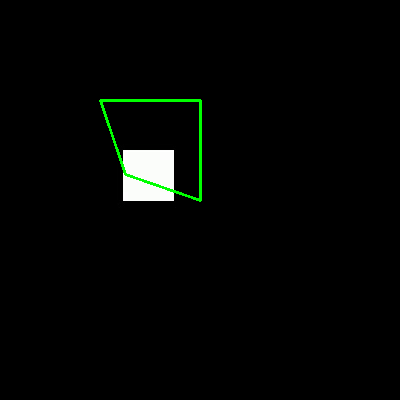

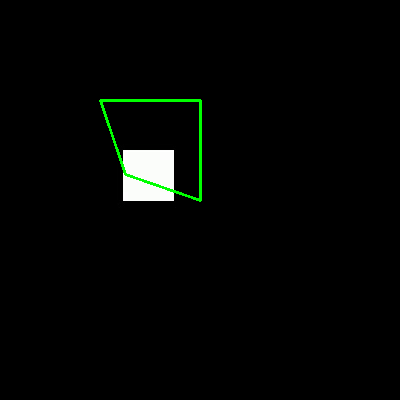

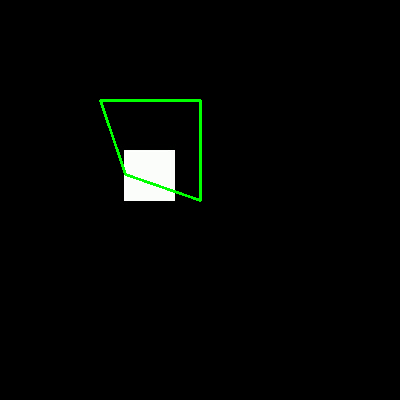

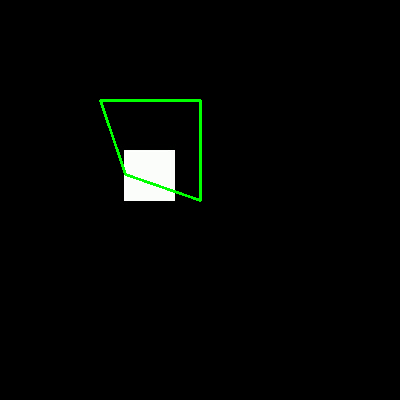

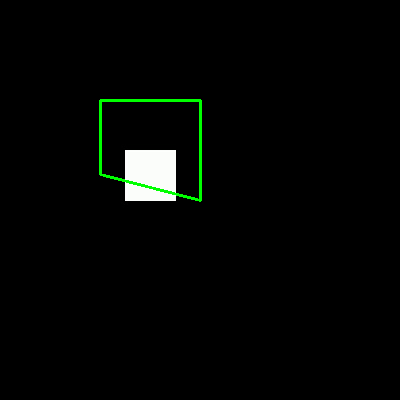

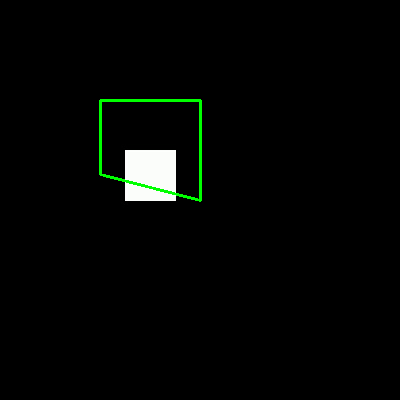

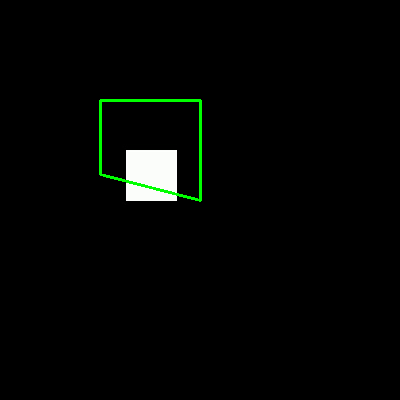

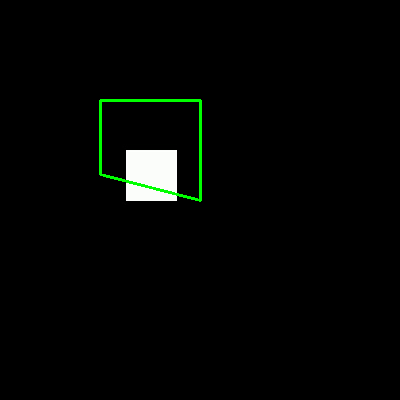

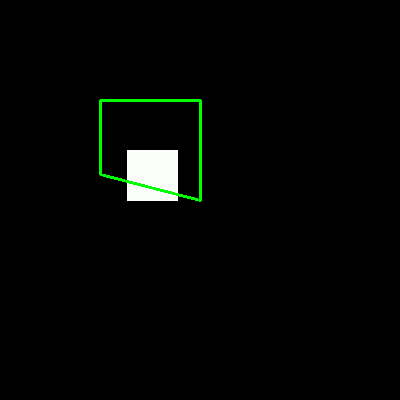

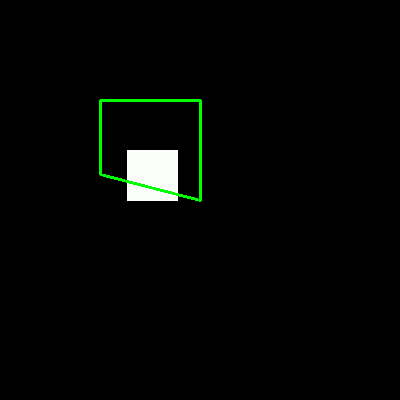

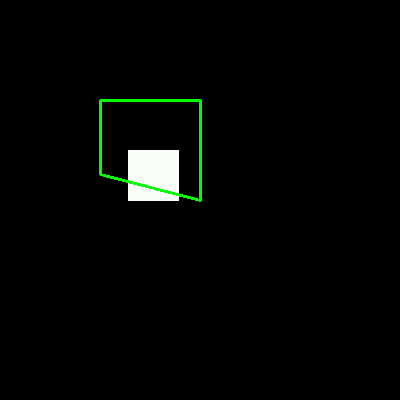

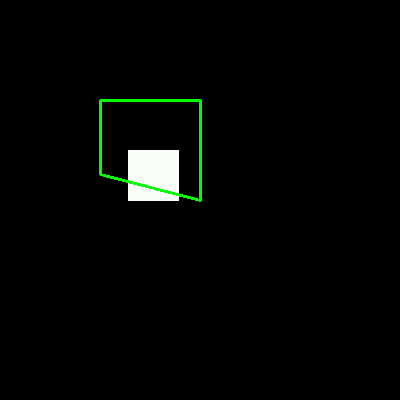

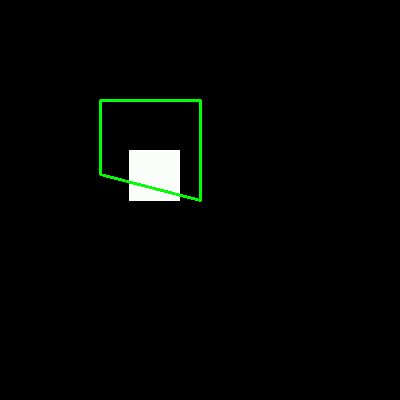

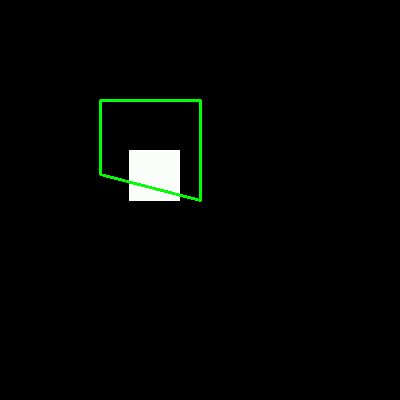

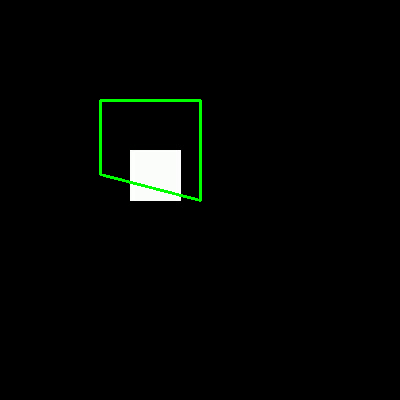

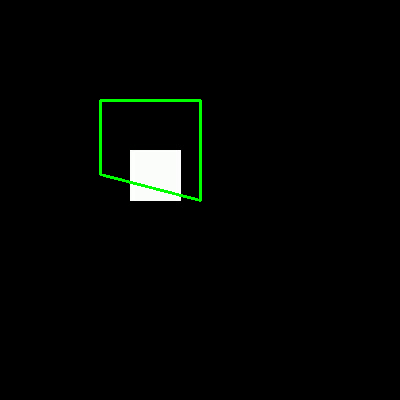

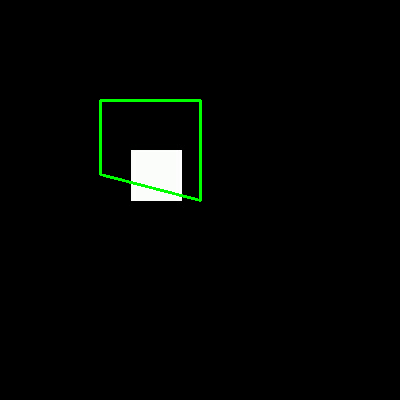

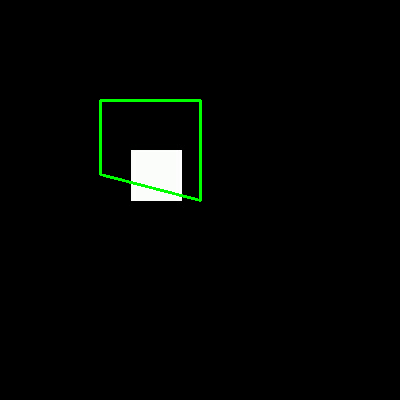

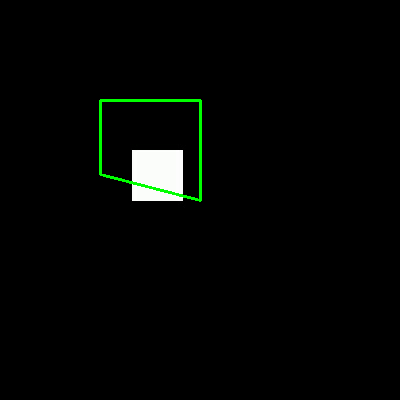

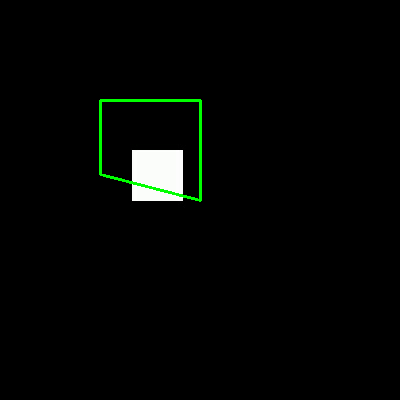

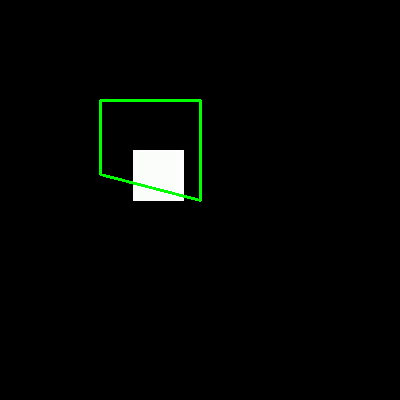

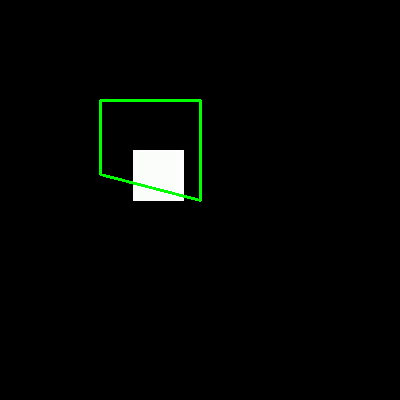

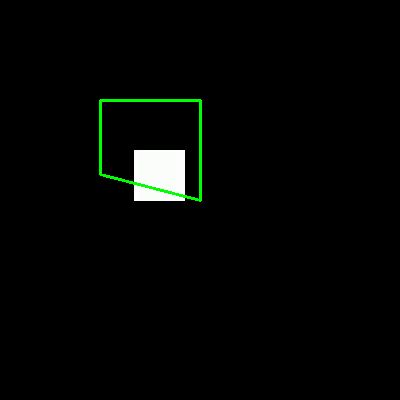

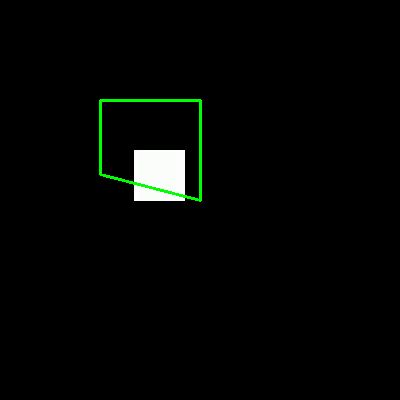

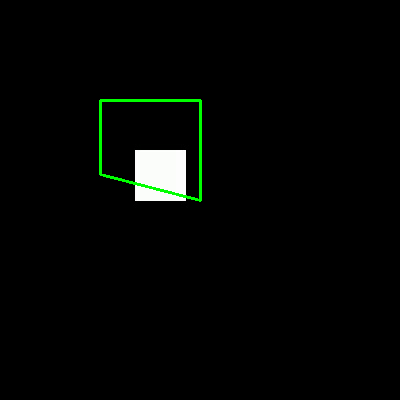

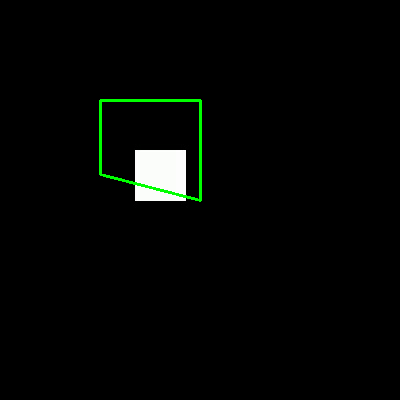

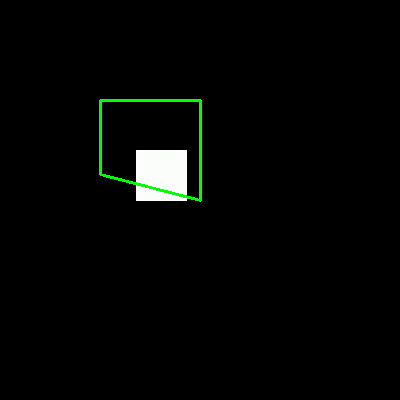

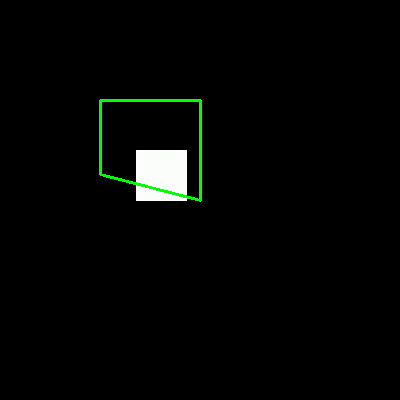

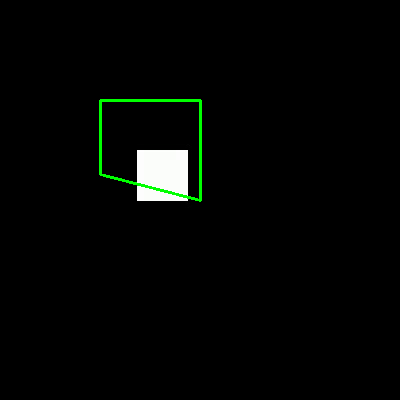

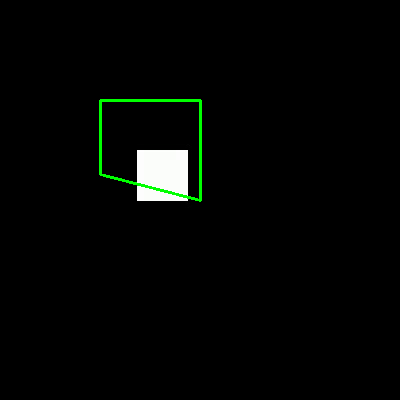

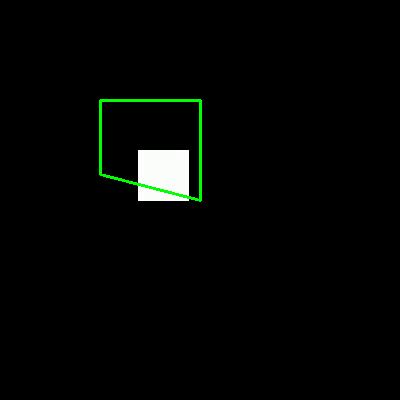

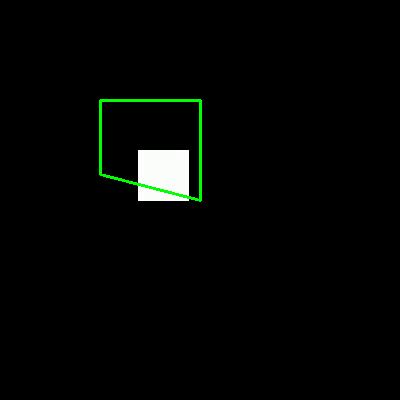

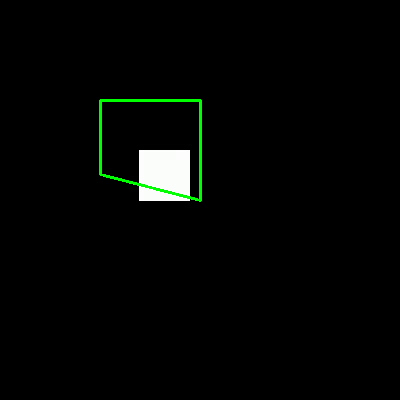

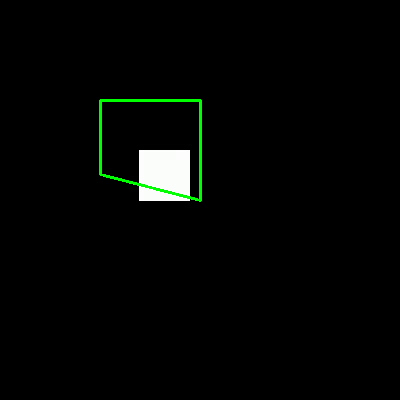

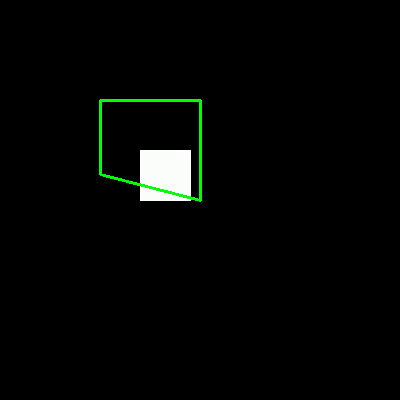

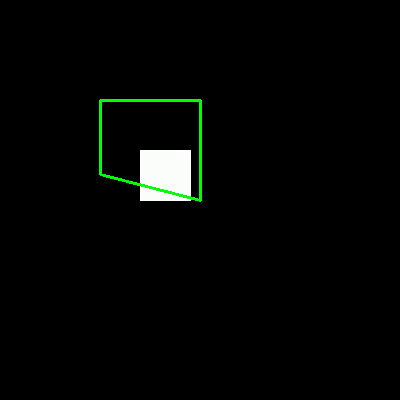

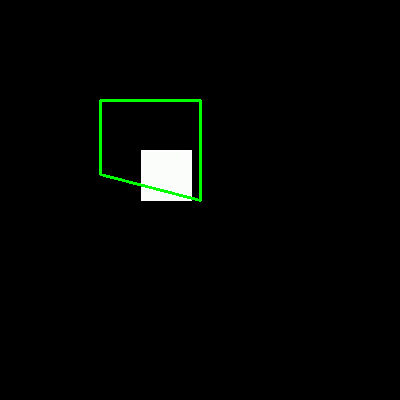

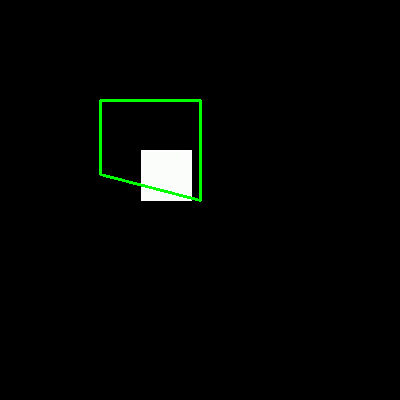

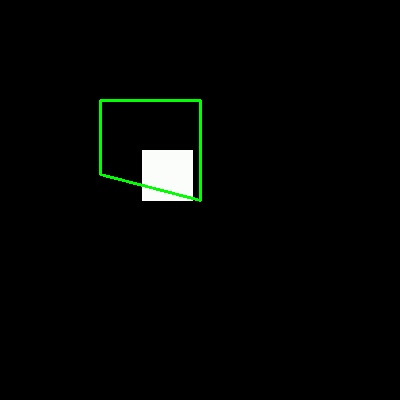

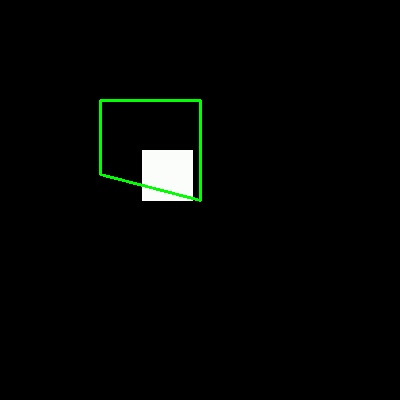

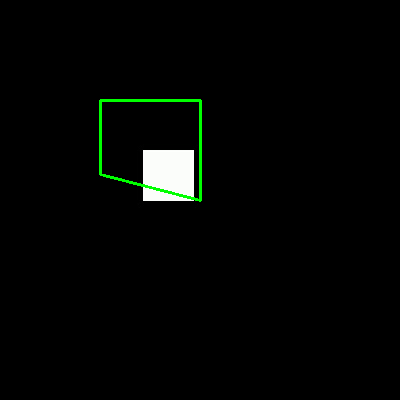

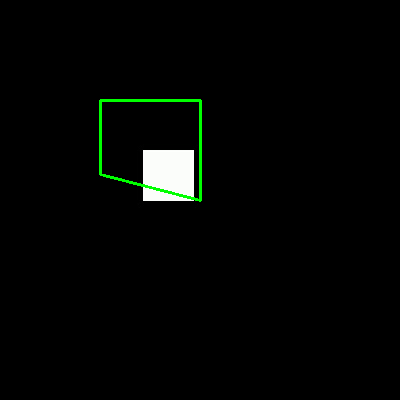

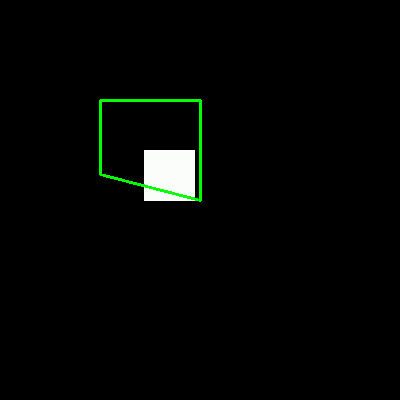

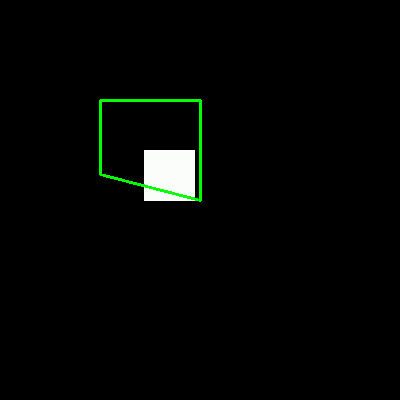

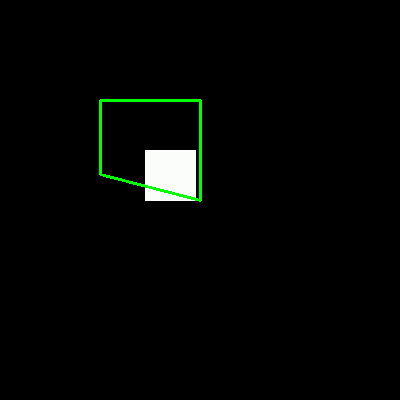

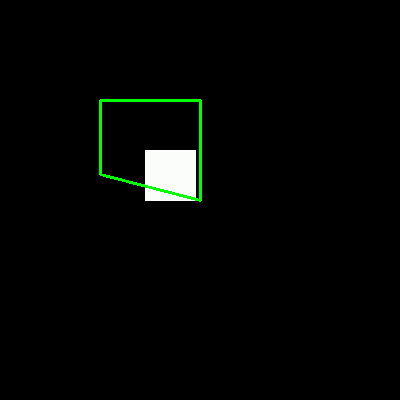

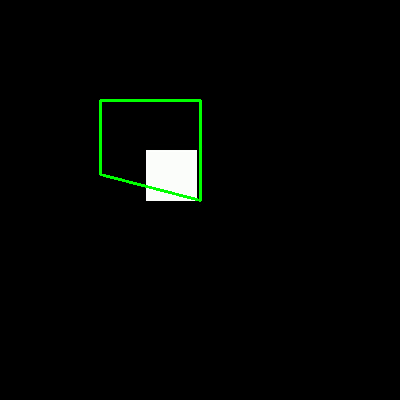

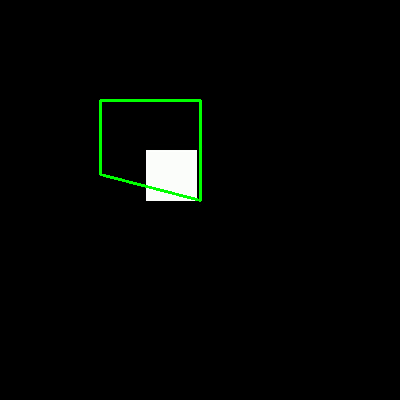

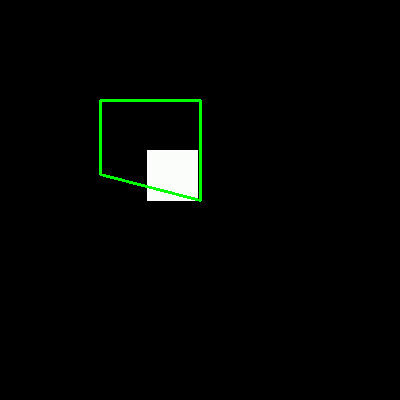

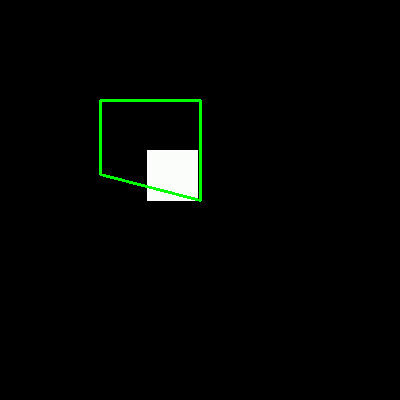

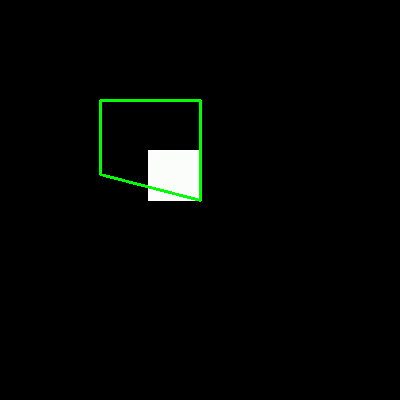

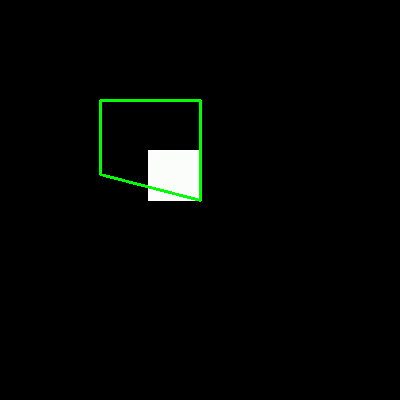

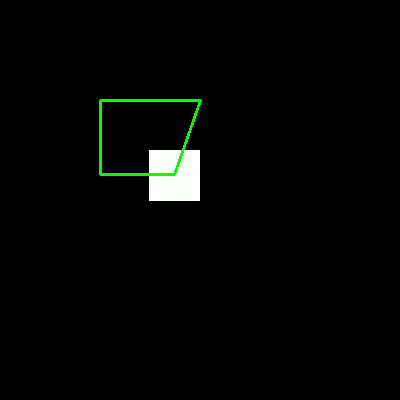

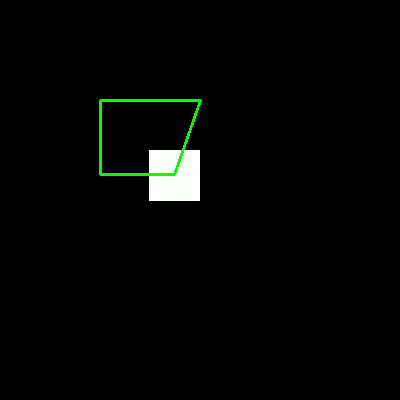

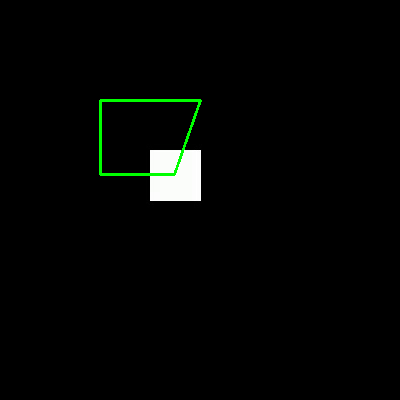

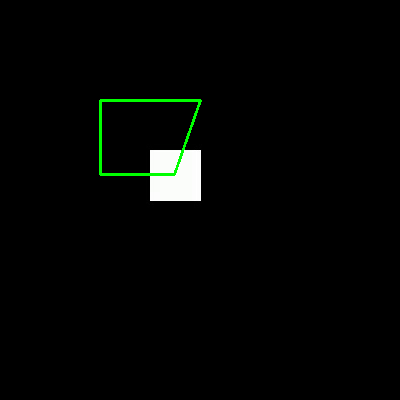

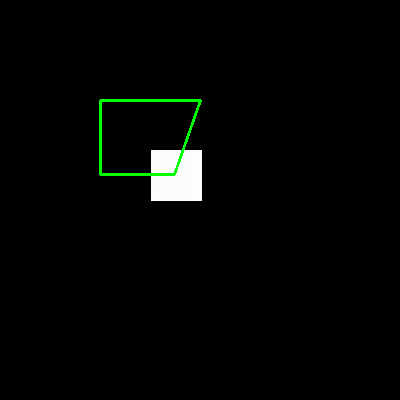

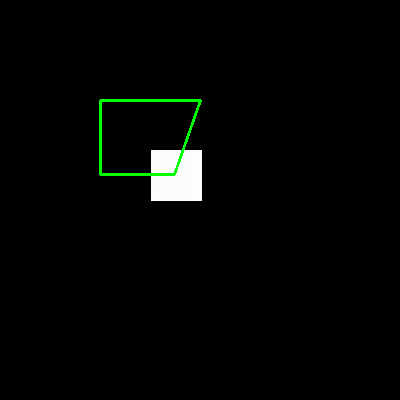

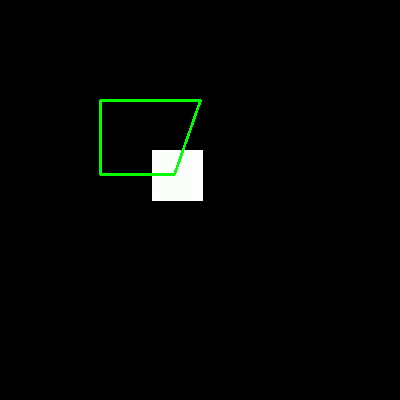

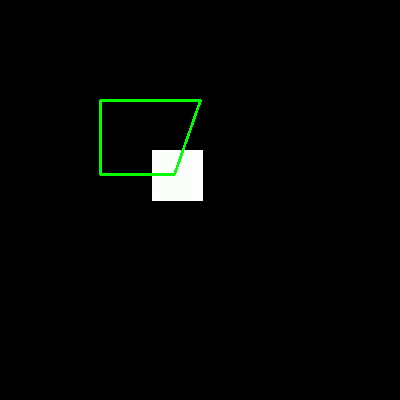

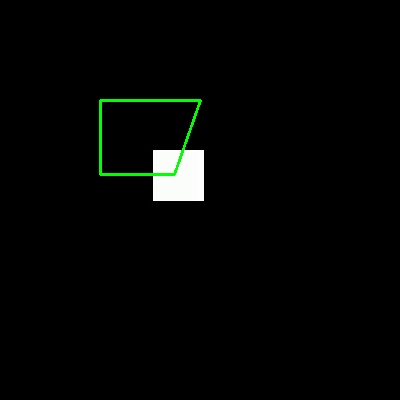

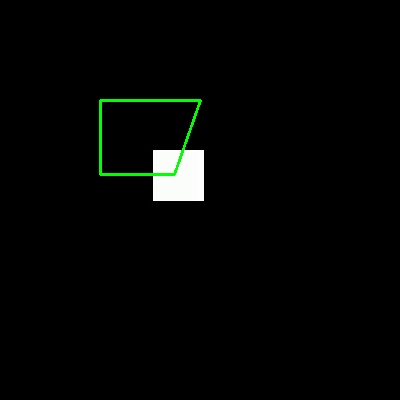

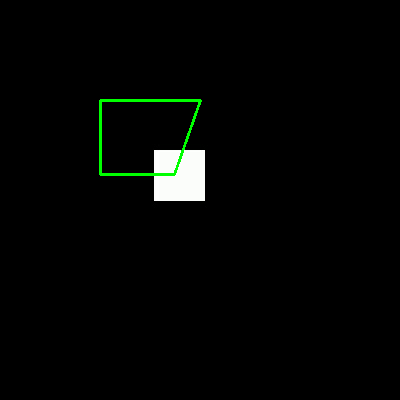

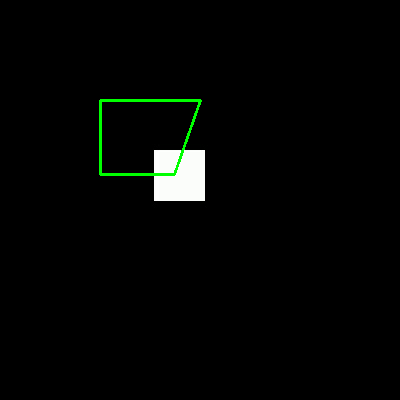

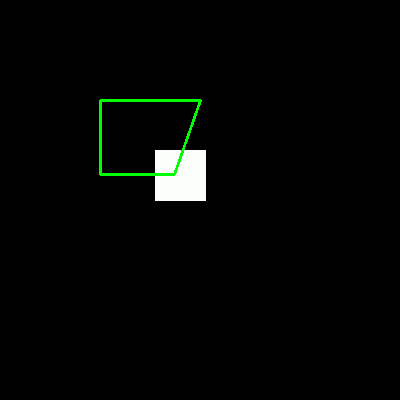

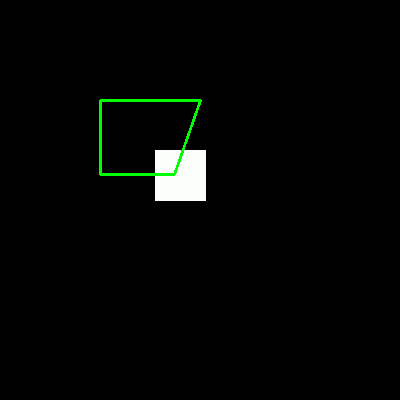

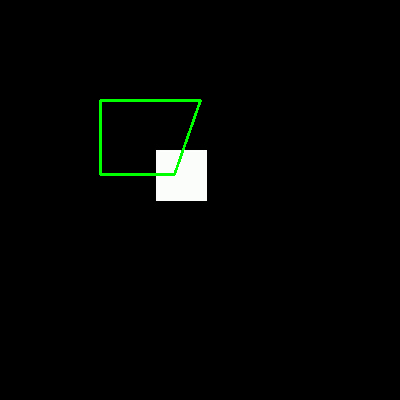

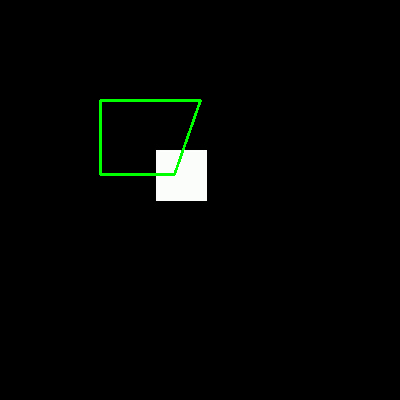

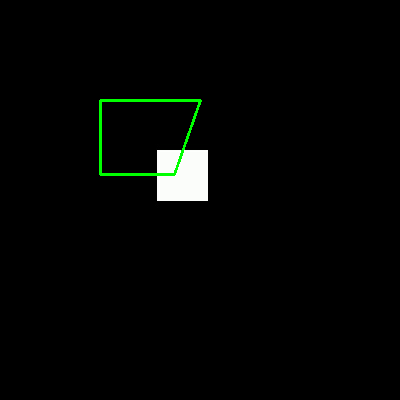

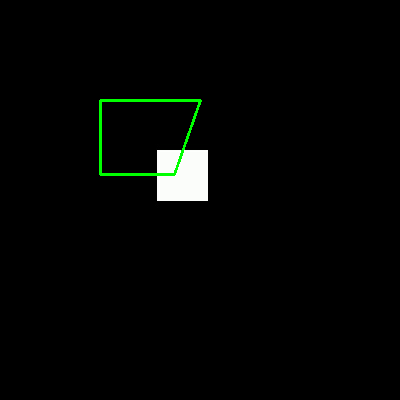

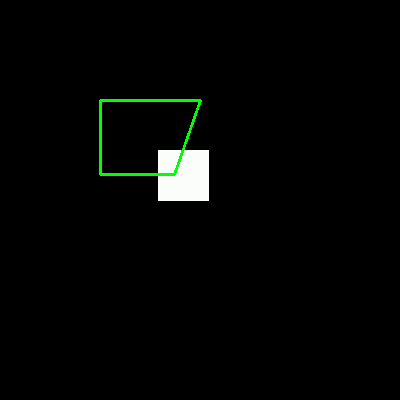

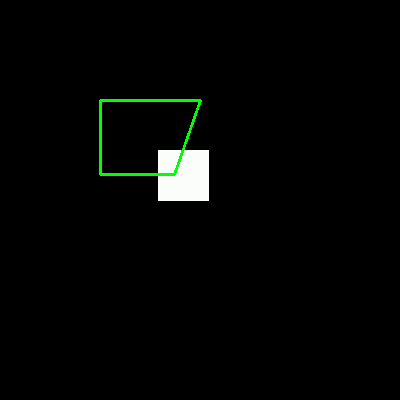

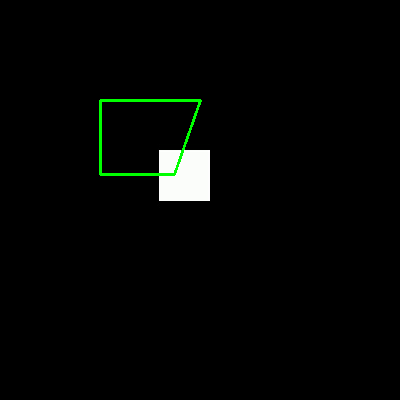

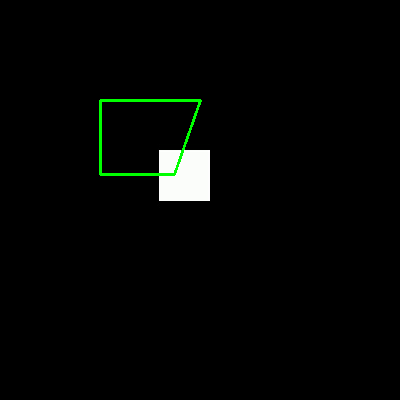

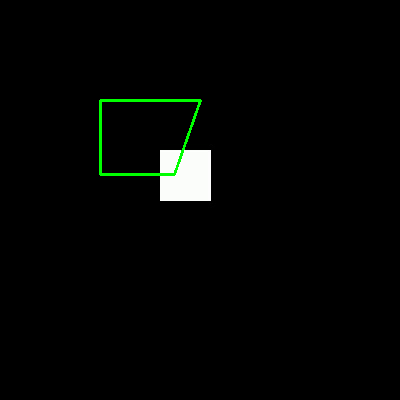

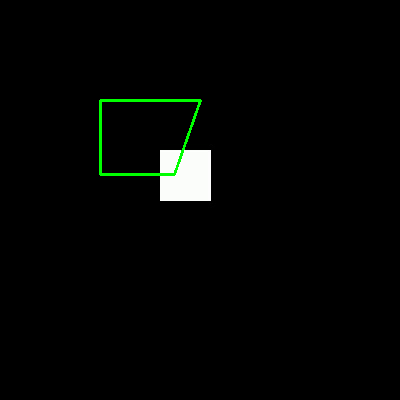

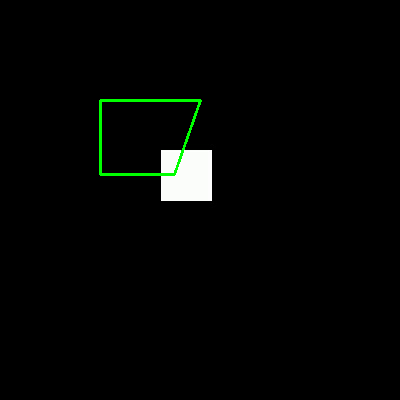

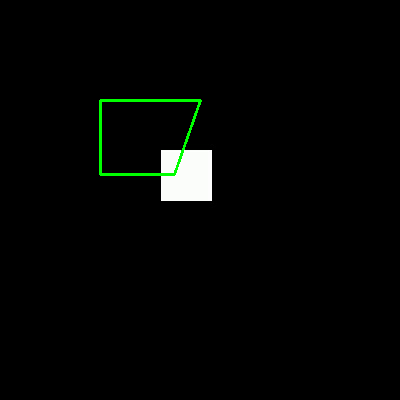

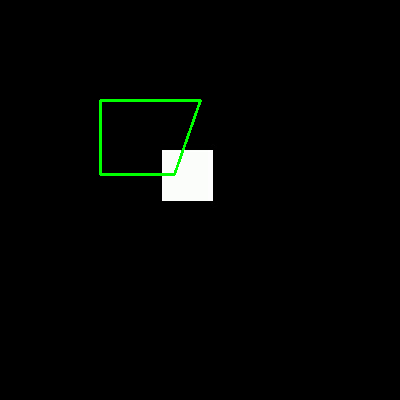

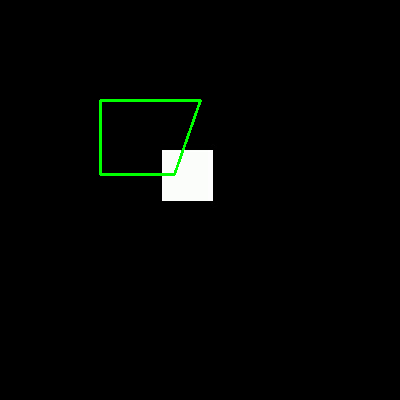

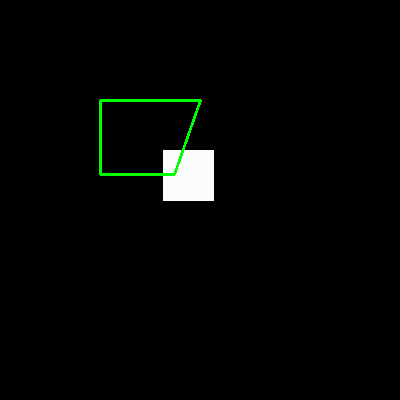

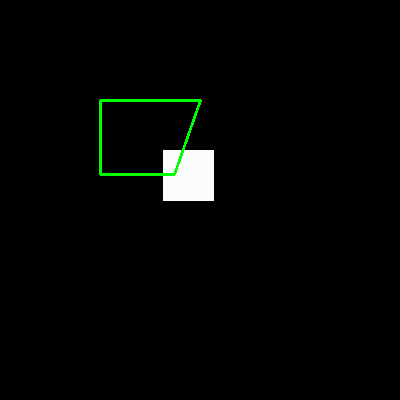

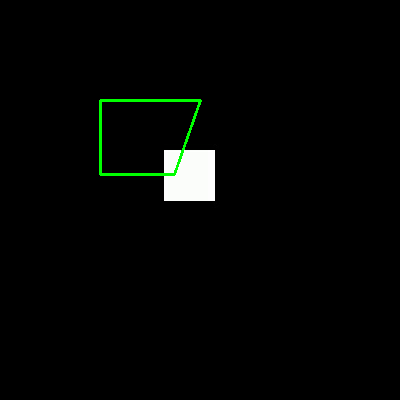

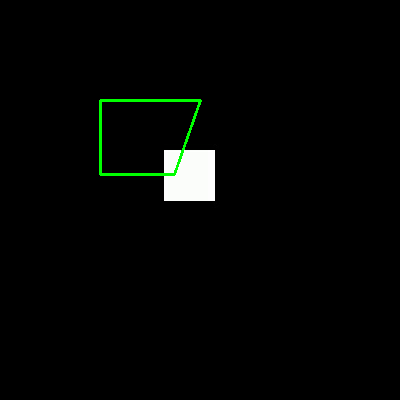

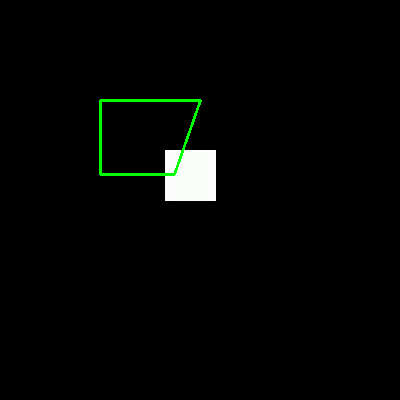

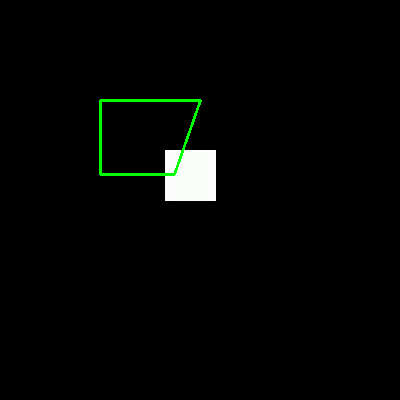

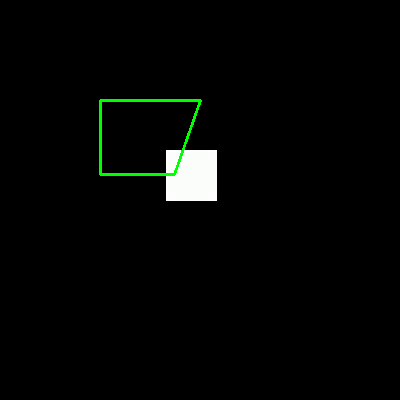

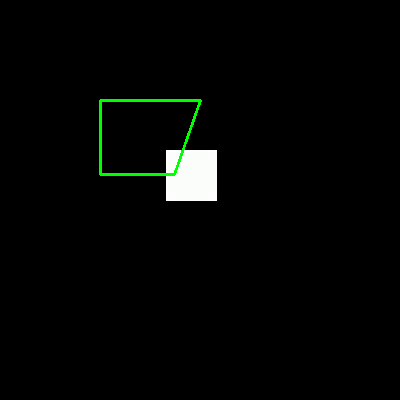

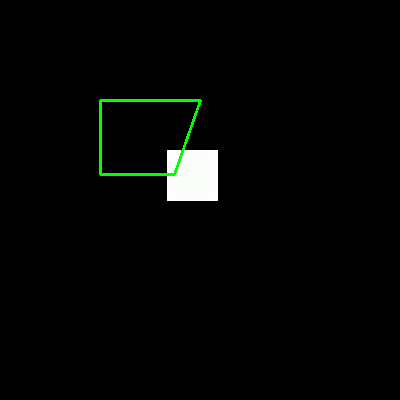

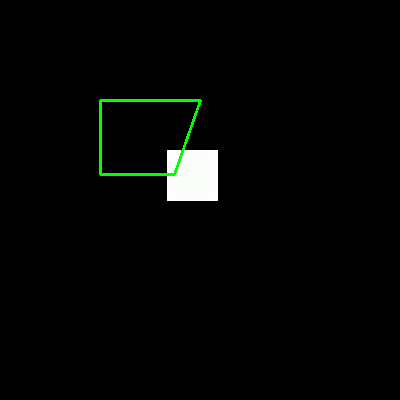

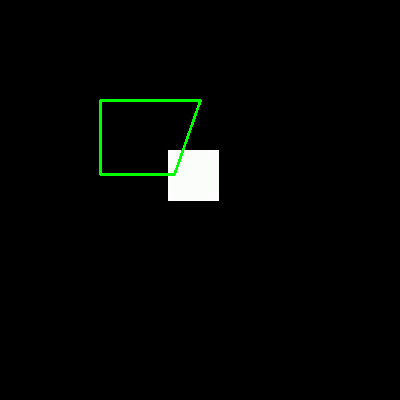

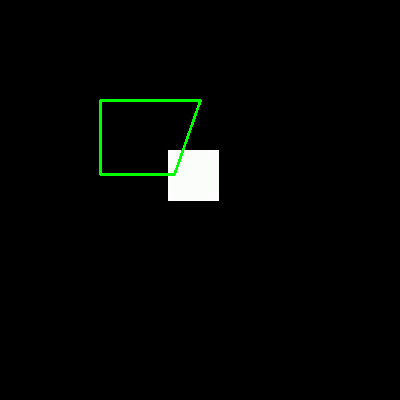

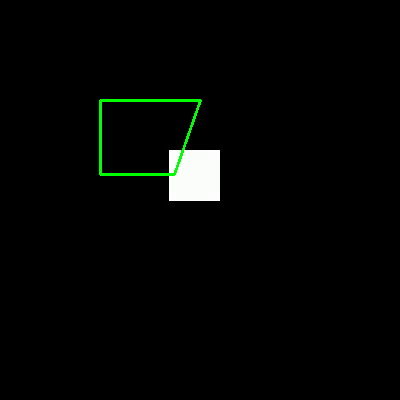

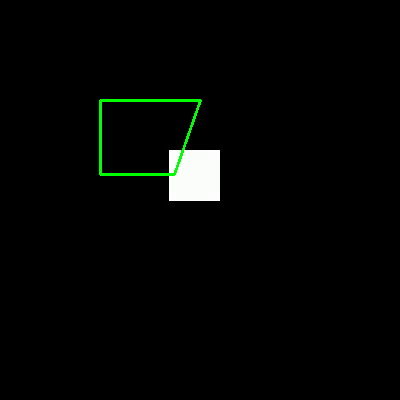

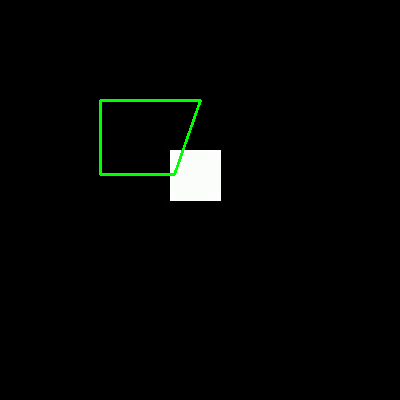

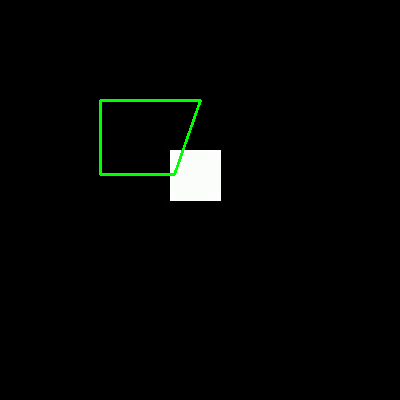

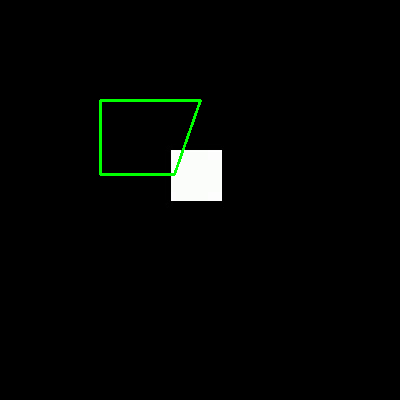

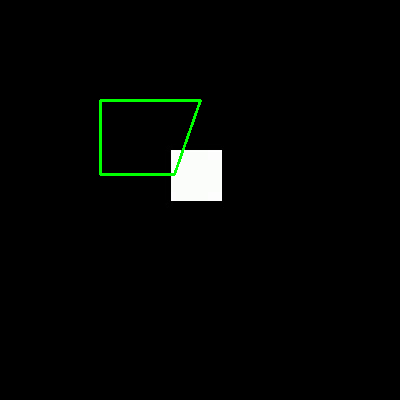

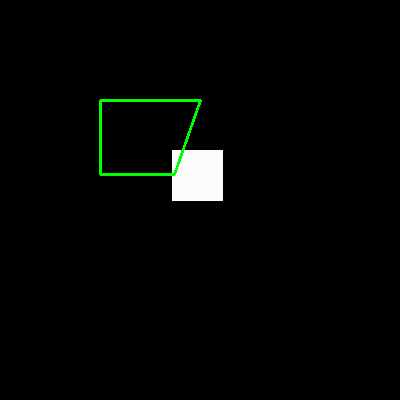

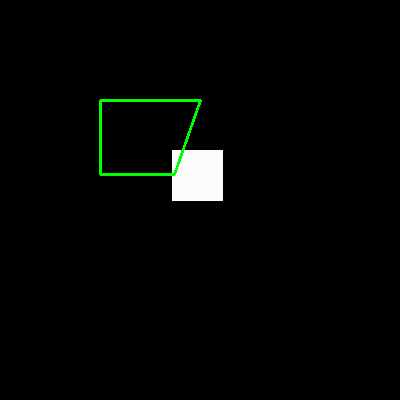

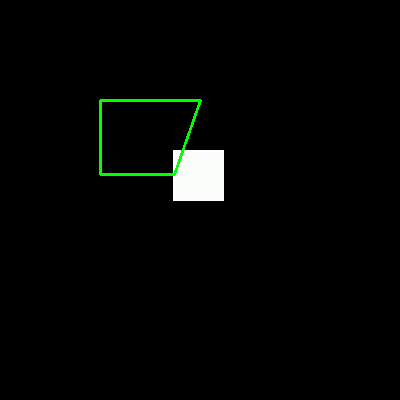

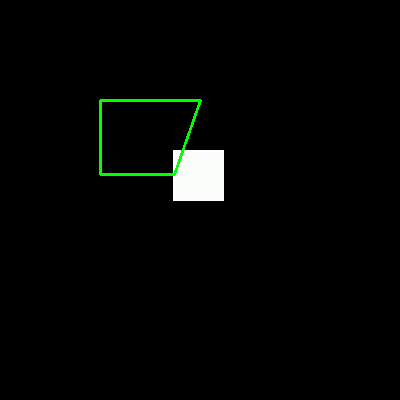

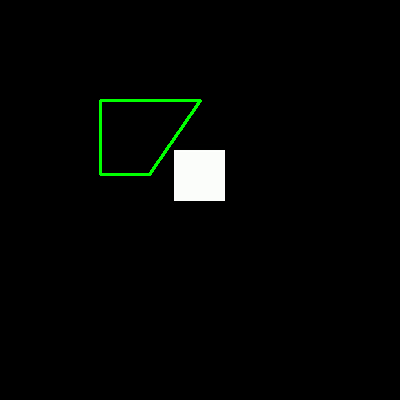

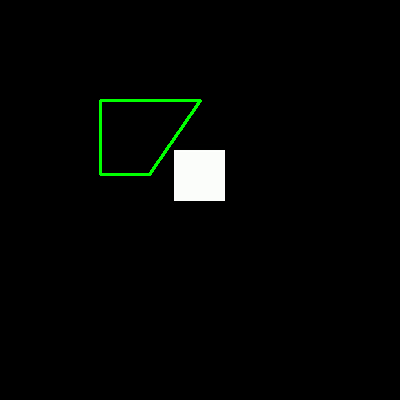

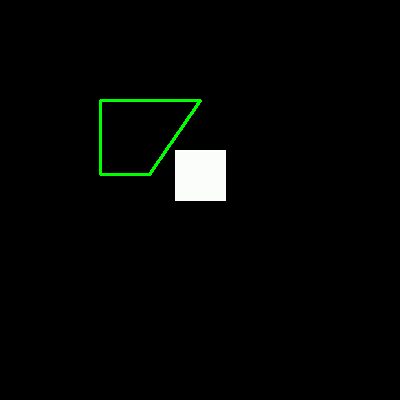

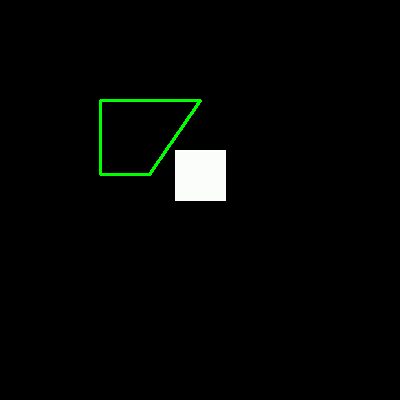

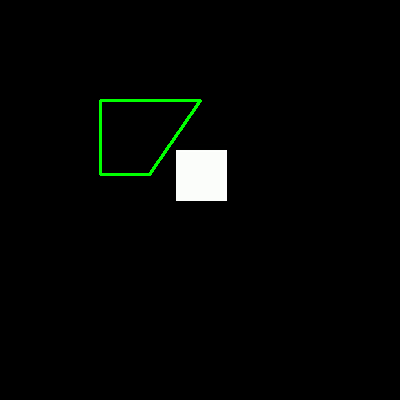

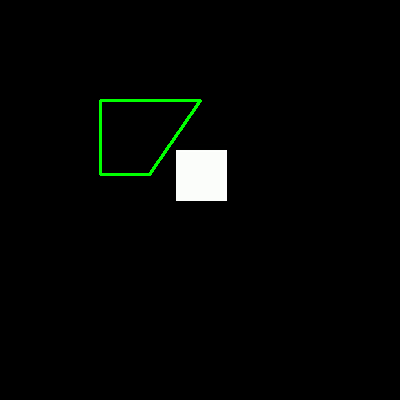

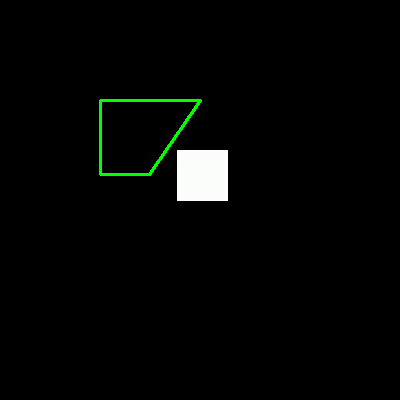

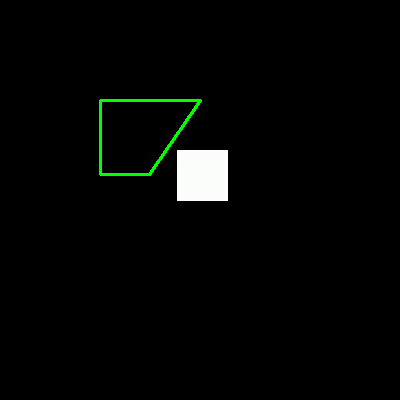

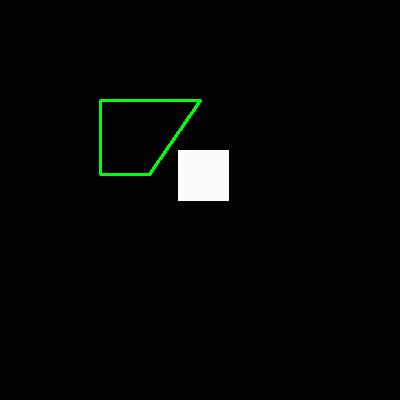

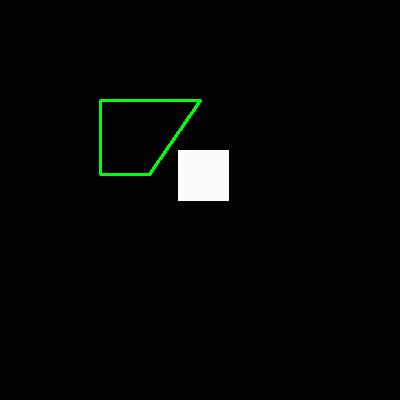

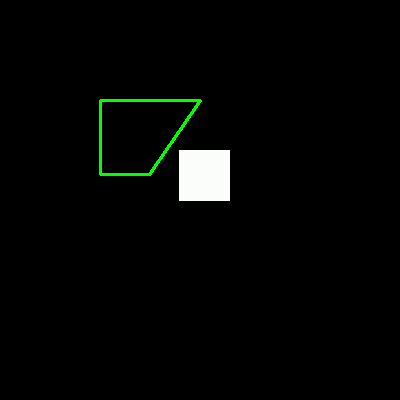

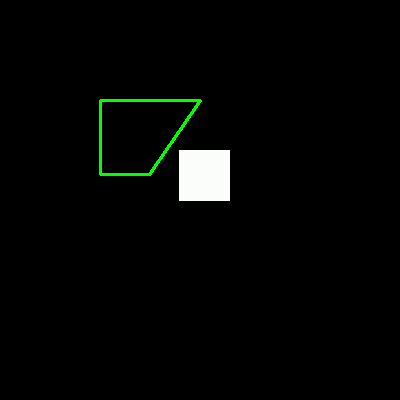

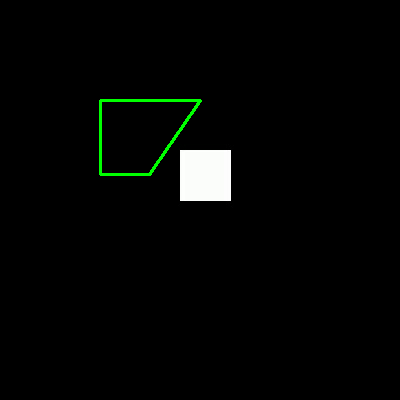

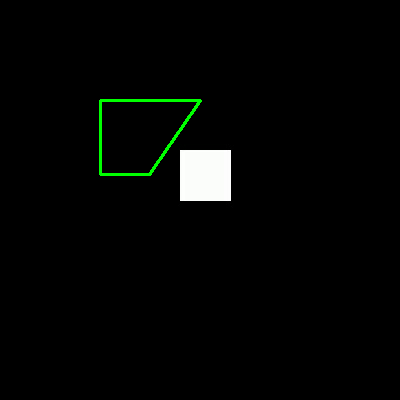

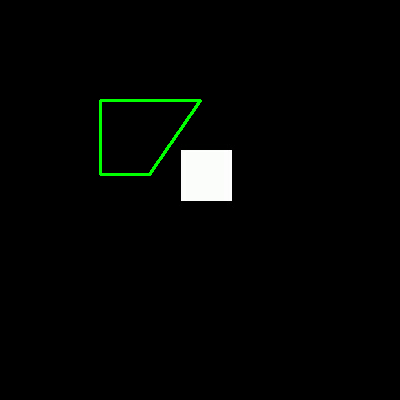

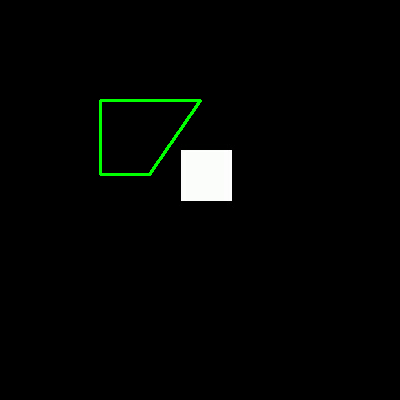

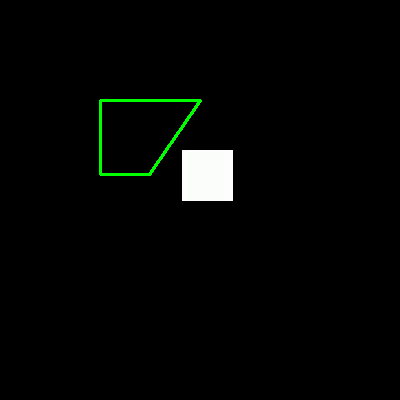

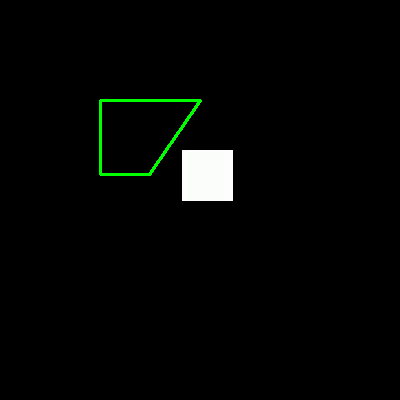

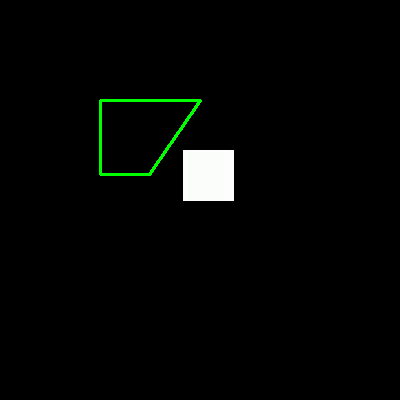

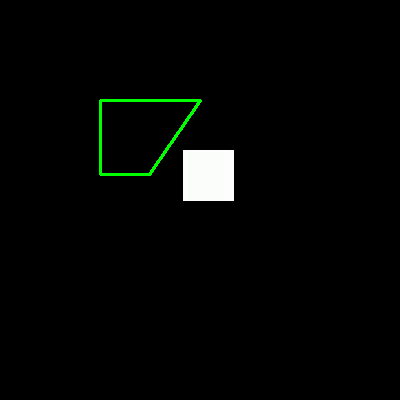

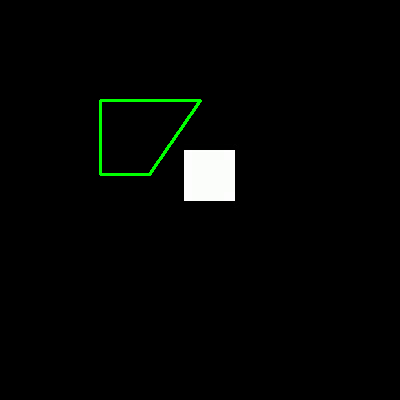

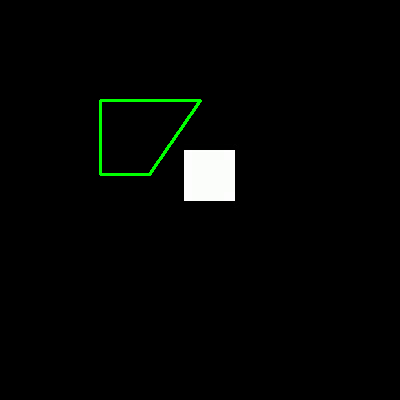

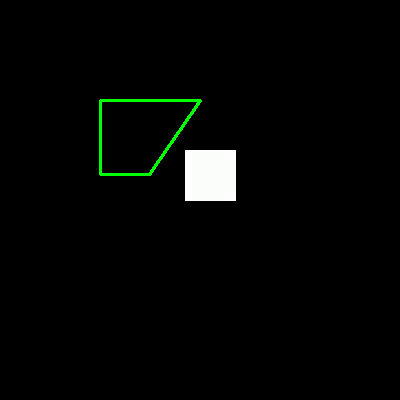

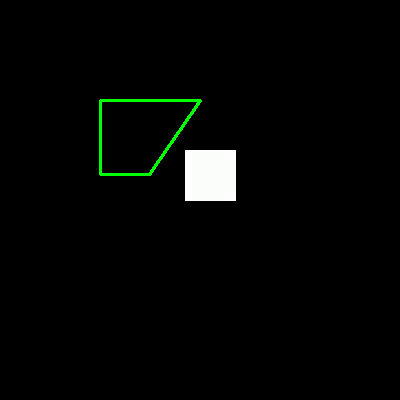

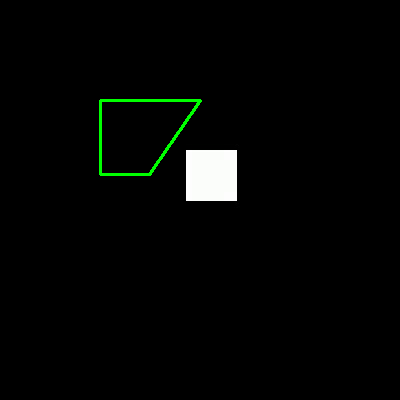

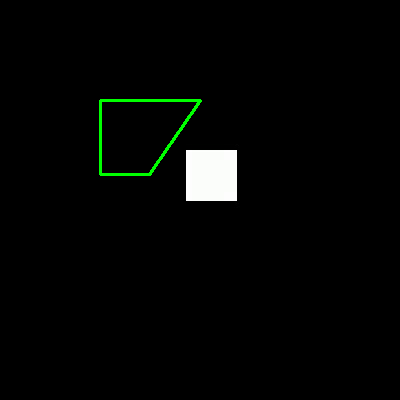

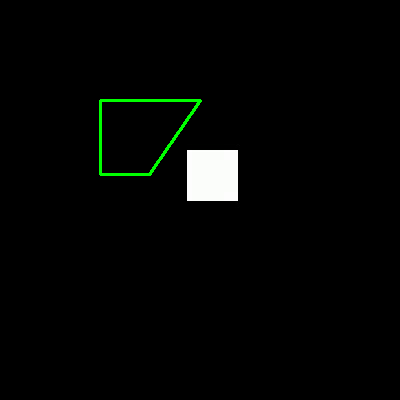

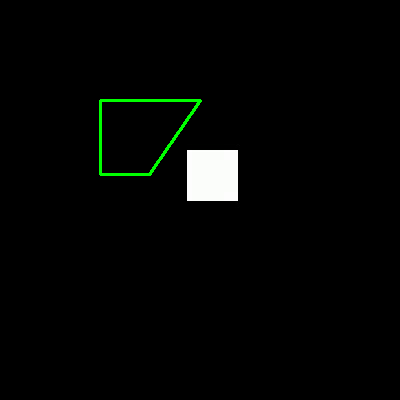

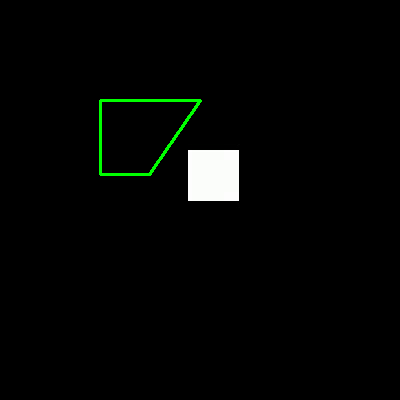

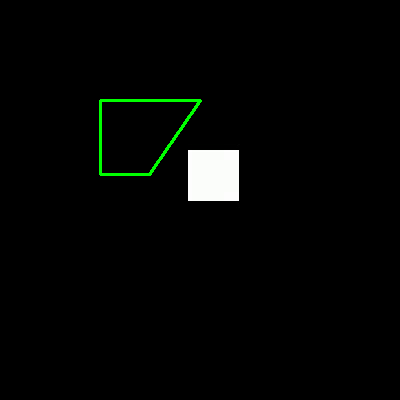

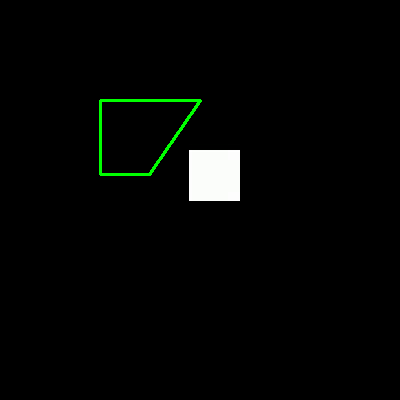

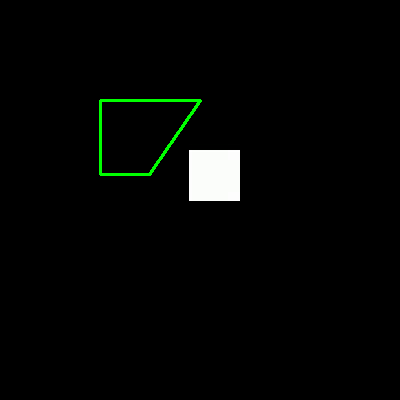

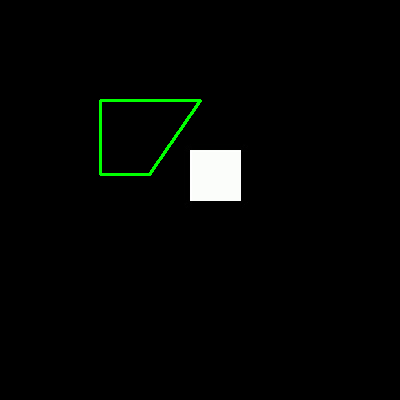

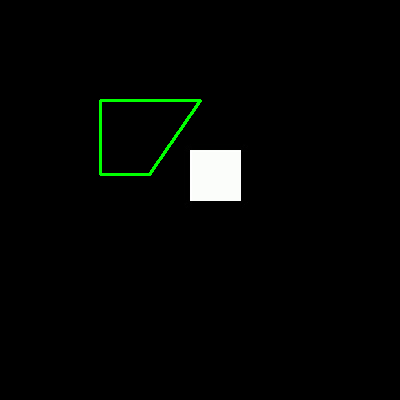

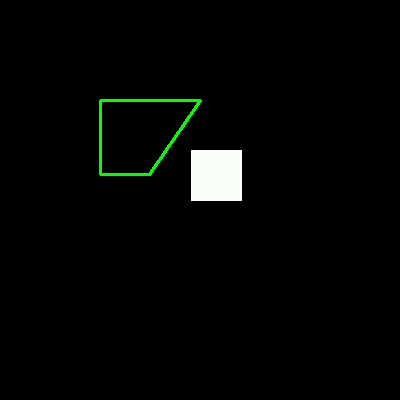

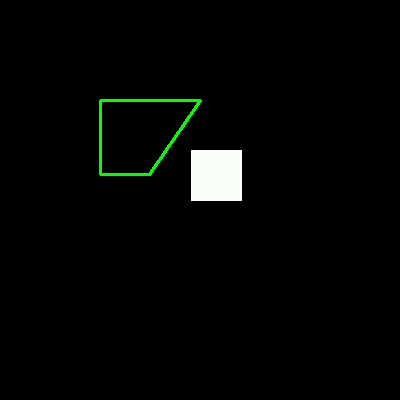

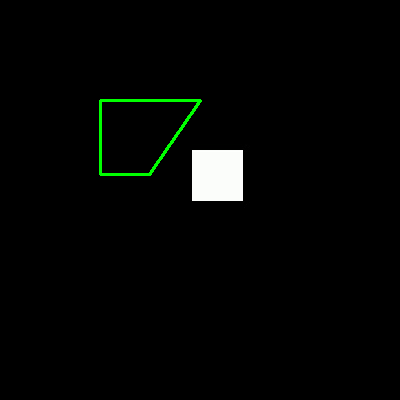

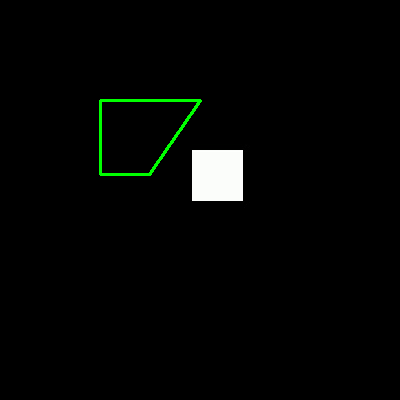

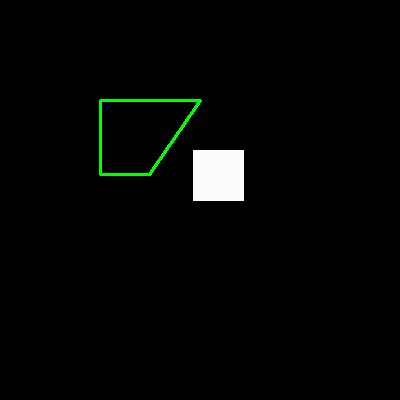

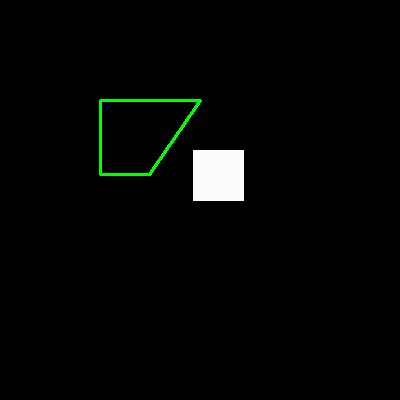

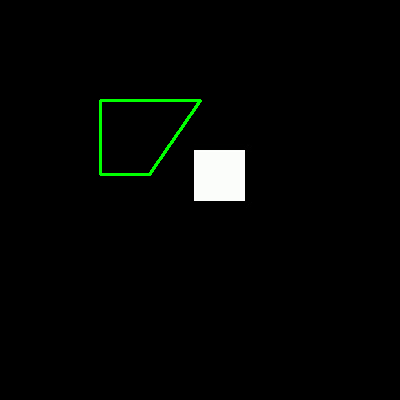

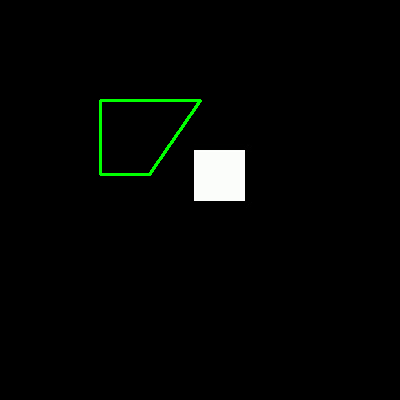

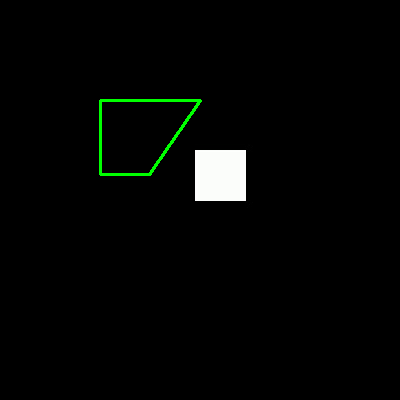

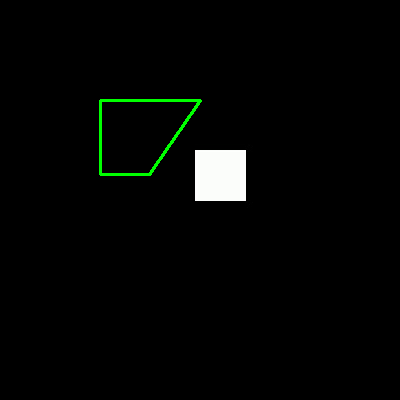

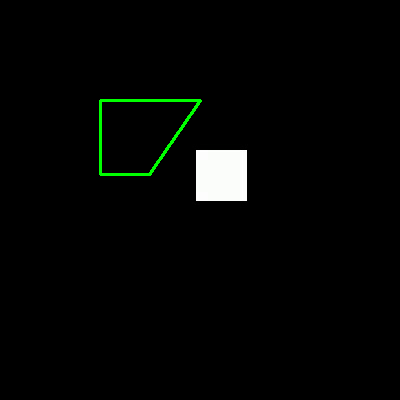

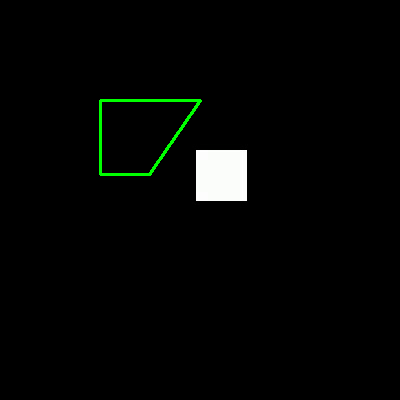

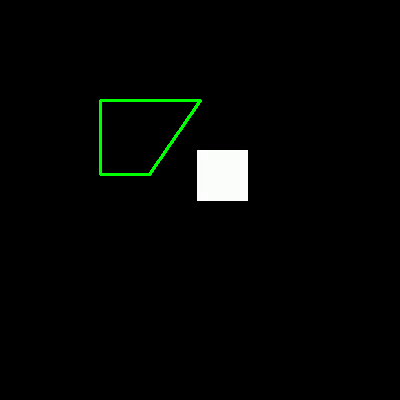

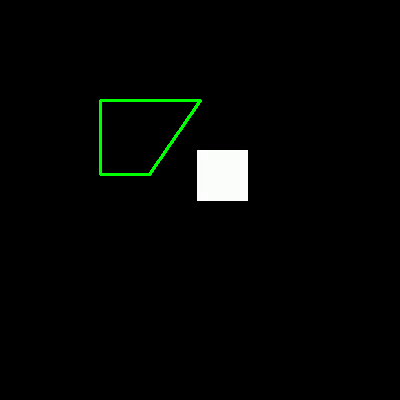

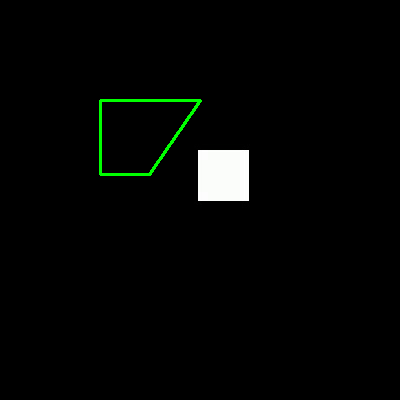

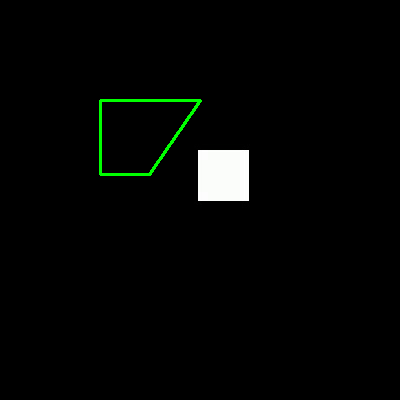

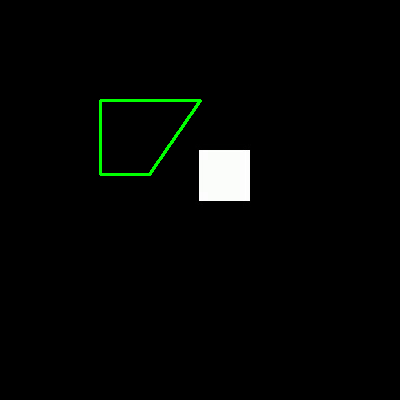

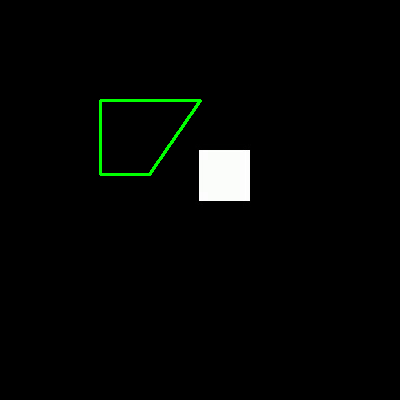

In [4]:
import cv2
import numpy as np

# Load video
cap = cv2.VideoCapture("video.mp4")

# Initial snake contour (rectangle)
points = np.array([[100,100],[200,100],[200,200],[100,200]], dtype=np.float32)

gamma = 0.2   # External force weight

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    h, w = frame.shape[:2]

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect edges
    edges = cv2.Canny(gray, 50, 150)

    # Compute gradient once per frame
    grad_y, grad_x = np.gradient(edges.astype(float))

    # Update snake points
    for i in range(len(points)):

        x = int(np.clip(points[i][0], 0, w-1))
        y = int(np.clip(points[i][1], 0, h-1))

        dx = grad_x[y, x]
        dy = grad_y[y, x]

        points[i] += gamma * np.array([dx, dy])

    # Draw contour
    cv2.polylines(frame, [points.astype(np.int32)], True, (0,255,0), 2)

    cv2_imshow("Dynamic Snake Tracking", frame)

    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()


In [18]:
from google.colab.patches import cv2_imshow

In [20]:
import numpy as np
import cv2

# Initialize particles
num_particles = 100
particles = np.random.rand(num_particles, 2) * 1500  # Random positions

def weight_particles(particles, observation):
    # Compute weights based on proximity to observation
    weights = np.exp(-np.linalg.norm(particles - observation, axis=1))
    return weights / weights.sum()

def resample_particles(particles, weights):
    indices = np.random.choice(range(num_particles), size=num_particles, p=weights)
    return particles[indices]

cap = cv2.VideoCapture('video_1.mp4')

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    observation = np.array([250, 250])  # Assume we detect the object here
    weights = weight_particles(particles, observation)
    particles = resample_particles(particles, weights)

    # Draw particles
    for p in particles:
        cv2.circle(frame, (int(p[0]), int(p[1])), 2, (0, 255, 0), -1)

    cv2_imshow(frame)
    if cv2.waitKey(30) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()



Output hidden; open in https://colab.research.google.com to view.

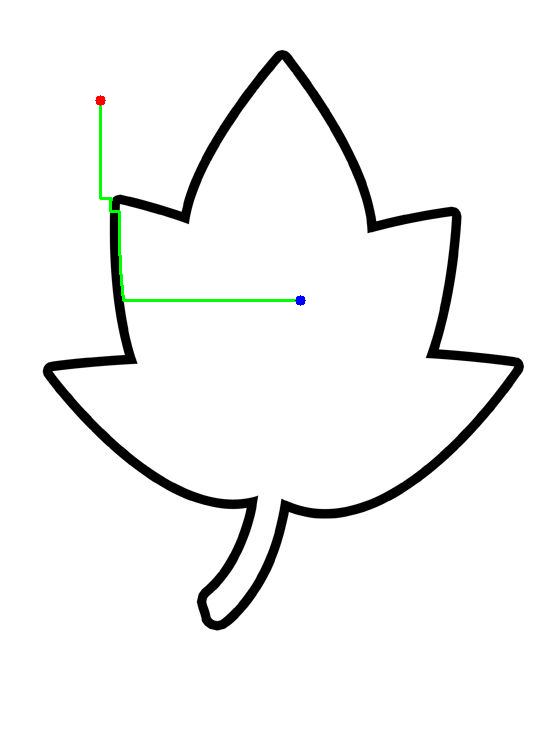

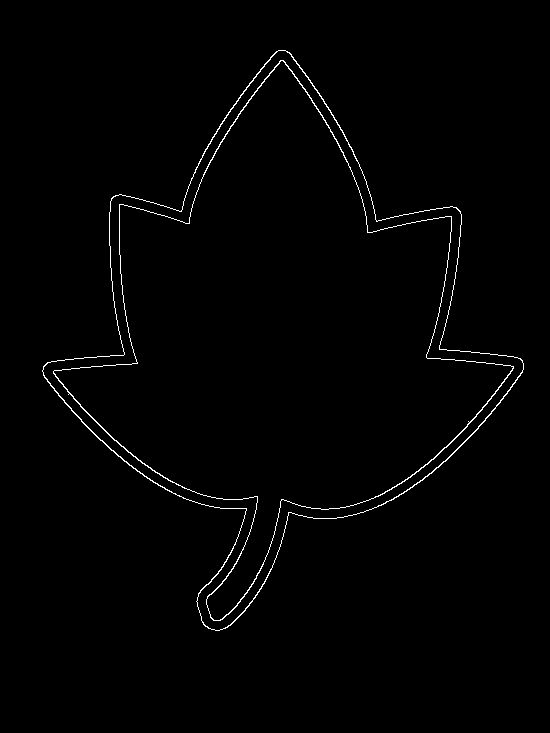

In [7]:
import cv2
import numpy as np
import heapq

# Load image
image = cv2.imread("leaf.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Edge detection
edges = cv2.Canny(gray, 50, 150)

h, w = edges.shape

# Seed point
seed = (100, 100)

# Dijkstra shortest path
def shortest_path(edges, seed):

    visited = np.zeros_like(edges, dtype=bool)
    dist = np.full(edges.shape, np.inf)

    pq = []

    dist[seed[1], seed[0]] = 0
    heapq.heappush(pq, (0, seed))

    parent = {}

    directions = [(-1,0),(1,0),(0,-1),(0,1)]

    while pq:

        d, (x,y) = heapq.heappop(pq)

        if visited[y,x]:
            continue

        visited[y,x] = True

        for dx,dy in directions:

            nx, ny = x+dx, y+dy

            if 0 <= nx < w and 0 <= ny < h:

                cost = 255 - edges[ny,nx]

                if dist[y,x] + cost < dist[ny,nx]:

                    dist[ny,nx] = dist[y,x] + cost
                    parent[(nx,ny)] = (x,y)

                    heapq.heappush(pq,(dist[ny,nx],(nx,ny)))

    return parent


parents = shortest_path(edges, seed)

# Choose target point
target = (300, 300)

# Reconstruct path
path = []
p = target

while p in parents:
    path.append(p)
    p = parents[p]

# Draw path
for point in path:
    cv2.circle(image, point, 1, (0,255,0), -1)

cv2.circle(image, seed, 5, (0,0,255), -1)
cv2.circle(image, target, 5, (255,0,0), -1)

cv2_imshow(image)
cv2_imshow(edges)

cv2.waitKey(0)
cv2.destroyAllWindows()

Pixel intensity at (10,20): 255
Intensity values (array):
[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


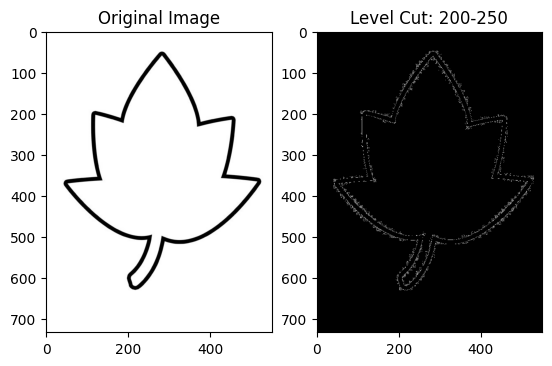

In [34]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread('leaf.jpg', cv2.IMREAD_GRAYSCALE)

# Define level cut range
low, high = 200, 250

# Apply level cut
level_cut = cv2.inRange(img, low, high)




# Show result
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
intensity = img[10, 20]
print("Pixel intensity at (10,20):", intensity)
print("Intensity values (array):")
print(img)
plt.subplot(1, 2, 2)
plt.imshow(level_cut, cmap='gray')
plt.title(f'Level Cut: {low}-{high}')
plt.show()


In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Function to check homogeneity
def is_homogeneous(region, threshold):
    return np.std(region) < threshold

# Split function
def split(image, threshold, min_size):
    h, w = image.shape

    if h <= min_size or w <= min_size:
        return [image]

    if is_homogeneous(image, threshold):
        return [image]

    h2, w2 = h // 2, w // 2

    regions = []
    regions += split(image[:h2, :w2], threshold, min_size)
    regions += split(image[:h2, w2:], threshold, min_size)
    regions += split(image[h2:, :w2], threshold, min_size)
    regions += split(image[h2:, w2:], threshold, min_size)

    return regions

# Merge function (simple visualization)
def merge(regions):
    merged = np.hstack(regions)
    return merged

# Load image
image = cv2.imread("leaf.jpg", 0)

# Apply split
regions = split(image, threshold=10, min_size=32)

# Merge regions for visualization
result = merge(regions)

# Display results
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image, cmap='gray')

plt.subplot(1,2,2)
plt.title("Split and Merge Result")
plt.imshow(result, cmap='gray')

plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 183 and the array at index 1 has size 91